In [ ]:
from google.colab import drive
drive.mount('/content/drive')

caminho1 = '/content/drive/MyDrive/mate/events.csv'
caminho2 = '/content/drive/MyDrive/mate/products.csv'
caminho3 = '/content/drive/MyDrive/mate/countries.csv'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Carregar os dados
df1 = pd.read_csv(caminho1)
df2 = pd.read_csv(caminho2)
df3 = pd.read_csv(caminho3)

# Conferir os dados
print(df1.head())
print(df2.head())
print(df3.head())


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  
     id        item_type
0  2103           Cereal
1  7940        Household
2  

#Tipos de dados de cada tabela

In [ ]:
df1.info()
df2.info()
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
mem

##Conferindo valores ausentes, tipo das colunas e corrigindo eventuais problemas

In [ ]:
print(df1.isnull().sum())
print(df2.isnull().sum())
print(df3.isnull().sum())

print(df1.dtypes)
print(df2.dtypes)
print(df3.dtypes)



Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64
id           0
item_type    0
dtype: int64
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object
id            int64
item_type    object
dtype: object
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object


Exclusão das 82 linhas de country code ausente, pois preciso delas pra fazer o JOIN com a tabela countries e não consigo descobrir qual país se trata. Se usar um valor como "unknown" outros valores como região e etc ficarão nulos o que me trará mais problemas.

Exclusão de valores faltantes na tabela countries.

Preenchimento de valores faltantes na coluna units sold com a média, ja que são apenas dois valores ausentes.


In [ ]:
# ------------------------------
# 1️⃣ TABELA EVENTS (df1)
# ------------------------------

# Excluir linhas sem Country Code (chave crítica)
df1 = df1.dropna(subset=['Country Code'])

# Preencher Units Sold ausente com a média
media_units = df1['Units Sold'].mean()
df1['Units Sold'] = df1['Units Sold'].fillna(media_units).round()

# Converter datas
df1['Order Date'] = pd.to_datetime(df1['Order Date'], errors='coerce')
df1['Ship Date'] = pd.to_datetime(df1['Ship Date'], errors='coerce')

# Remover duplicatas
df1 = df1.drop_duplicates()

# Limpar espaços extras
df1['Order Priority'] = df1['Order Priority'].str.strip()
df1['Sales Channel'] = df1['Sales Channel'].str.strip()
df1['Country Code'] = df1['Country Code'].str.strip()

# Verificação de anomalias
print("EVENTS - Unidades vendidas negativas ou zero:")
print(df1[df1['Units Sold'] <= 0])
print("EVENTS - Preços ou custos negativos:")
print(df1[(df1['Unit Price'] < 0) | (df1['Unit Cost'] < 0)])
print("EVENTS - Ship Date antes do Order Date:")
print(df1[df1['Ship Date'] < df1['Order Date']])

# ------------------------------
# 2️⃣ TABELA PRODUCTS (df2)
# ------------------------------

# Remover duplicatas
df2 = df2.drop_duplicates()

# Conferir valores ausentes
print("\nPRODUCTS - Valores ausentes por coluna:")
print(df2.isnull().sum())

# Limpar strings e espaços extras
df2['item_type'] = df2['item_type'].str.strip()

# Conferir tipos de dados
df2['id'] = df2['id'].astype(int)  # garantir que é inteiro

# ------------------------------
# 3️⃣ TABELA COUNTRIES (df3)
# ------------------------------

# Remover duplicatas
df3 = df3.drop_duplicates()

# Preencher region e sub-region ausentes com "Unknown"
df3['region'] = df3['region'].replace('nan', pd.NA).fillna('Unknown')
df3['sub-region'] = df3['sub-region'].replace('nan', pd.NA).fillna('Unknown')

# Opcional: alpha-2 ausente, preencher com "Unknown"
df3['alpha-2'] = df3['alpha-2'].replace('nan', pd.NA).fillna('Unknown')


# Conferir valores ausentes
print("\nCOUNTRIES - Valores ausentes por coluna:")
print(df3.isnull().sum())

# Limpar strings e espaços extras
for col in ['name', 'alpha-2', 'alpha-3', 'region', 'sub-region']:
    df3[col] = df3[col].astype(str).str.strip()

# Converter códigos de país para maiúsculas para consistência
df3['alpha-2'] = df3['alpha-2'].str.upper()
df3['alpha-3'] = df3['alpha-3'].str.upper()

# Verificação básica: regiões e sub-regiões
print("\nCOUNTRIES - Regiões únicas:")
print(df3['region'].unique())
print("\nCOUNTRIES - Sub-regiões únicas:")
print(df3['sub-region'].unique())

# ------------------------------
# 4️⃣ Preparação para merge futura
# ------------------------------

# Garantir que chaves para merge estejam consistentes
df1['Country Code'] = df1['Country Code'].str.upper()
df1['Product ID'] = df1['Product ID'].astype(int)


EVENTS - Unidades vendidas negativas ou zero:
Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Order Priority, Country Code, Product ID, Sales Channel, Units Sold, Unit Price, Unit Cost]
Index: []
EVENTS - Preços ou custos negativos:
Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Order Priority, Country Code, Product ID, Sales Channel, Units Sold, Unit Price, Unit Cost]
Index: []
EVENTS - Ship Date antes do Order Date:
Empty DataFrame
Columns: [Order ID, Order Date, Ship Date, Order Priority, Country Code, Product ID, Sales Channel, Units Sold, Unit Price, Unit Cost]
Index: []

PRODUCTS - Valores ausentes por coluna:
id           0
item_type    0
dtype: int64

COUNTRIES - Valores ausentes por coluna:
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64

COUNTRIES - Regiões únicas:
['Asia' 'Europe' 'Africa' 'Oceania' 'Americas' 'Unknown']

COUNTRIES - Sub-regiões únicas:
['Southern Asia' 'Northern Europe' 'Southern Europe' 'N

#Transformando as 3 tabelas em um só dataframe

Aproveitei pra excluir colunas que não serão mais necessárias, como alpha-2 e alpha-3 e id


In [ ]:
# 1️⃣ Merge events com products
df_merged = df1.merge(
    df2,
    left_on='Product ID',
    right_on='id',
    how='left'  # mantém todos os eventos, mesmo que o Product ID não exista em products
)

# 2️⃣ Merge resultante com countries
df_merged = df_merged.merge(
    df3,
    left_on='Country Code',
    right_on='alpha-3',
    how='left'  # mantém todos os eventos
)

# 3️⃣ Limpeza pós-merge

# Se houver valores ausentes nas colunas de produto ou país, podemos preencher ou identificar
df_merged['item_type'] = df_merged['item_type'].fillna('Unknown')
df_merged['region'] = df_merged['region'].fillna('Unknown')
df_merged['sub-region'] = df_merged['sub-region'].fillna('Unknown')

# 4️⃣ Conferir resultado
print("Dimensões do DataFrame final:", df_merged.shape)
print("Valores ausentes por coluna:")
print(df_merged.isnull().sum())

# Exclusão de colunas desnecessárias
df_merged = df_merged.drop(columns=['alpha-2', 'alpha-3', "id"])

df_merged.head(10)

Dimensões do DataFrame final: (1248, 17)
Valores ausentes por coluna:
Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
id                0
item_type         0
name              0
alpha-2           0
alpha-3           0
region            0
sub-region        0
dtype: int64


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost,item_type,name,region,sub-region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe
5,103499639,2013-04-20,2013-06-06,L,FRA,4594,Online,6698.0,9.33,6.92,Fruits,France,Europe,Western Europe
6,103762280,2011-11-12,2011-12-14,M,ESP,5988,Online,4419.0,154.06,90.93,Vegetables,Spain,Europe,Southern Europe
7,103832662,2012-09-19,2012-10-20,H,HRV,7331,Offline,5247.0,255.28,159.42,Baby Food,Croatia,Europe,Southern Europe
8,104008615,2011-01-23,2011-02-22,M,DEU,2103,Online,7315.0,205.70,117.11,Cereal,Germany,Europe,Western Europe
9,104165685,2012-02-19,2012-03-06,L,ARM,7940,Online,3796.0,668.27,502.54,Household,Armenia,Asia,Western Asia


Com do dataframe pronto, a última correção que fiz agora foi padronizar o nome de todas as colunas usando letras minúsculas e snake case, mudei o nome da coluna de países de name para country, e item_type para product_category

In [ ]:
# Padronizar colunas para snake_case e minúsculas
df_merged.columns = (
    df_merged.columns
    .str.strip()          # remove espaços extras
    .str.lower()          # transforma em minúsculas
    .str.replace(' ', '_')  # substitui espaços por underscore
    .str.replace('-', '_')  # substitui hífens por underscore
)

df_merged.rename(columns={'name': 'country'}, inplace=True)
df_merged.rename(columns={'item_type': 'product_category'}, inplace=True)

# Conferir resultado
df_merged.head(5)



,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,product_category,country,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe


##Adicionando novas colunas para facilitar futuros cálculos, revenue e profit

In [ ]:
# Criar coluna revenue
df_merged['revenue'] = df_merged['units_sold'] * df_merged['unit_price']

# Criar coluna profit
df_merged['profit'] = df_merged['revenue'] - (df_merged['units_sold'] * df_merged['unit_cost'])

# Conferir as novas colunas
df_merged.head(5)


,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,product_category,country,region,sub_region,revenue,profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,Online,650.0,205.70,117.11,Cereal,Norway,Europe,Northern Europe,133705.00,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,Offline,1993.0,205.70,117.11,Cereal,Serbia,Europe,Southern Europe,409960.10,176559.87
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,Online,1171.0,109.28,35.84,Clothes,Montenegro,Europe,Southern Europe,127966.88,85998.24
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,Offline,7648.0,47.45,31.79,Beverages,Serbia,Europe,Southern Europe,362897.60,119767.68
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,Online,2220.0,651.21,524.96,Office Supplies,Slovakia,Europe,Eastern Europe,1445686.20,280275.00


##Analisando métricas gerais comuns

In [ ]:
# Número total de pedidos
total_pedidos = df_merged['order_id'].nunique()

# Número total de unidades vendidas
total_unidades = df_merged['units_sold'].sum()

# Receita total
total_revenue = df_merged['revenue'].sum()

# Lucro total
total_profit = df_merged['profit'].sum()

# Número de países atendidos
total_paises = df_merged['country_code'].nunique()

# Número de produtos diferentes
total_produtos = df_merged['product_category'].nunique()

# Número de regiões atendidas
total_regioes = df_merged['region'].nunique()

total_sub_regioes = df_merged['sub_region'].nunique()


# Exibir as métricas de forma organizada
print(f"Número total de pedidos: {total_pedidos}")
print(f"Número total de unidades vendidas: {total_unidades}")
print(f"Receita total: ${total_revenue:,.2f}")
print(f"Lucro total: ${total_profit:,.2f}")
print(f"Número total de países atendidos: {total_paises}")
print(f"Número total de categoria produtos: {total_produtos}")
print(f"Número total de regiões atendidas: {total_regioes}")
print(f"Número total de sub regiões atendidas: {total_sub_regioes}")


Número total de pedidos: 1248
Número total de unidades vendidas: 6181577.0
Receita total: $1,601,478,191.12
Lucro total: $474,116,468.84
Número total de países atendidos: 45
Número total de categoria produtos: 12
Número total de regiões atendidas: 2
Número total de sub regiões atendidas: 5


##Gráfico métricas gerais

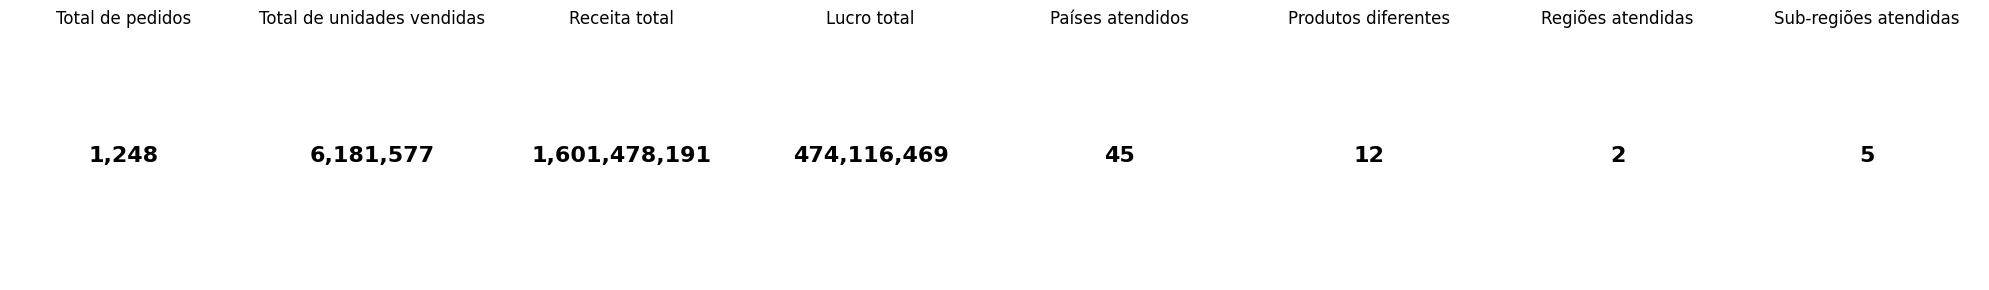

In [ ]:
# Lista de métricas e valores
kpis_labels = [
    'Total de pedidos',
    'Total de unidades vendidas',
    'Receita total',
    'Lucro total',
    'Países atendidos',
    'Produtos diferentes',
    'Regiões atendidas',
    'Sub-regiões atendidas'
]

kpis_values = [
    total_pedidos,
    total_unidades,
    total_revenue,
    total_profit,
    total_paises,
    total_produtos,
    total_regioes,
    total_sub_regioes
]

# Criar figura
fig, axes = plt.subplots(1, len(kpis_labels), figsize=(20, 3))

# Ajuste para iterar sobre cada eixo e KPI
for ax, label, value in zip(axes, kpis_labels, kpis_values):
    ax.axis('off')  # remover eixos
    ax.text(0.5, 0.5, f"{value:,.0f}" if isinstance(value, (int, float)) else value,
            fontsize=16, fontweight='bold', ha='center', va='center')
    ax.set_title(label, fontsize=12)

plt.tight_layout()
plt.show()


#Médias gerais

In [ ]:
# Médias por pedido
avg_revenue_per_order = df_merged['revenue'].mean()
avg_profit_per_order = df_merged['profit'].mean()
avg_cost_per_order = (df_merged['unit_cost'] * df_merged['units_sold']).mean()


# Margem média (%)
profit_margin = (total_profit / total_revenue) * 100

print("===== MÉDIAS GERAIS =====")
print(f"Faturamento médio por venda: {avg_revenue_per_order:,.2f}")
print(f"Lucro médio por venda: {avg_profit_per_order:,.2f}")
print(f"Custo médio por venda: {avg_cost_per_order:,.2f}")
print(f"Margem de lucro: {profit_margin:.2f}%")


===== MÉDIAS GERAIS =====
Faturamento médio por venda: 1,283,235.73
Lucro médio por venda: 379,901.02
Custo médio por venda: 903,334.71
Margem de lucro: 29.60%


##Gráfico médias gerais

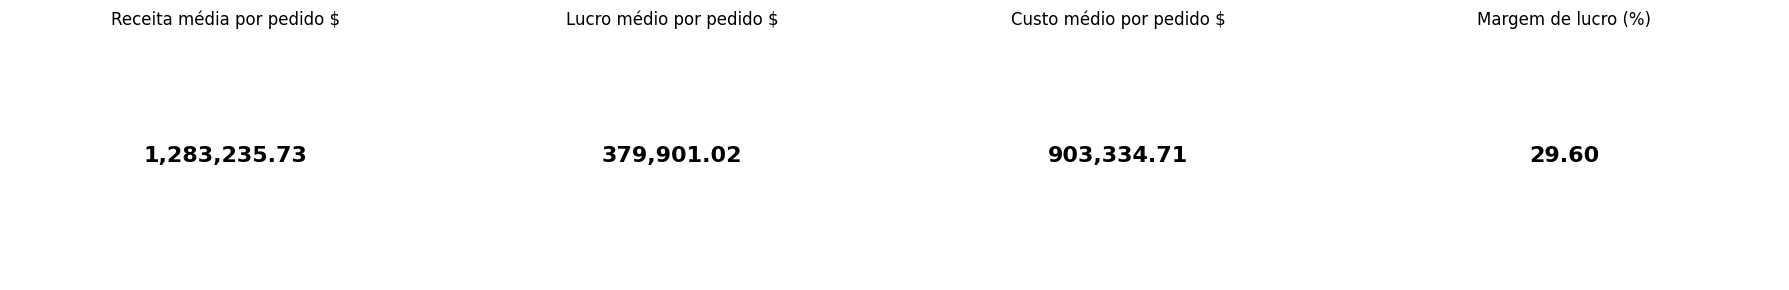

In [ ]:
# Lista de métricas e valores
kpi_labels = [
    'Receita média por pedido $',
    'Lucro médio por pedido $',
    'Custo médio por pedido $',
    'Margem de lucro (%)'
]

kpi_values = [
    avg_revenue_per_order,
    avg_profit_per_order,
    avg_cost_per_order,
    profit_margin
]

# Criar figura com 4 cards
fig, axes = plt.subplots(1, len(kpi_labels), figsize=(18, 3))

for ax, label, value in zip(axes, kpi_labels, kpi_values):
    ax.axis('off')  # remover eixos
    # Formatação para porcentagem ou valores monetários
    display_value = f"{value:,.2f}" if 'Margin' not in label else f"{value:.2f}%"
    ax.text(0.5, 0.5, display_value, fontsize=16, fontweight='bold', ha='center', va='center')
    ax.set_title(label, fontsize=12)

plt.tight_layout()
plt.show()


##Métricas por países

In [ ]:
# Cálculo de mnétricas básicas agregadas por país
country_summary = df_merged.groupby('country').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    total_orders=('order_id', 'count')
).reset_index()

# Cálculo de métricas derivadas
country_summary['avg_revenue_per_order'] = (
    country_summary['total_revenue'] / country_summary['total_orders']
)

country_summary['avg_profit_per_order'] = (
    country_summary['total_profit'] / country_summary['total_orders']
)

country_summary['profit_margin_%'] = (
    country_summary['total_profit'] / country_summary['total_revenue']
) * 100

# Ordenar por receita (ranking principal)
country_summary = country_summary.sort_values(
    by='total_revenue',
    ascending=False
)

country_summary.head(10)



,country,total_units_sold,total_revenue,total_profit,total_orders,avg_revenue_per_order,avg_profit_per_order,profit_margin_%
10,Czech Republic,142446.0,53543932.14,13635593.78,31,1.727224e+06,439857.863871,25.466179
43,Ukraine,164577.0,53252317.54,14804925.74,33,1.613707e+06,448634.113333,27.801467
6,Bosnia and Herzegovina,153545.0,50117508.49,13257602.77,33,1.518712e+06,401745.538485,26.453036
26,Macedonia,203078.0,49222085.25,13684099.95,32,1.538190e+06,427628.123437,27.800732
36,San Marino,192228.0,47883708.48,13792992.81,40,1.197093e+06,344824.820250,28.805189
1,Andorra,185686.0,47756693.17,15410036.63,40,1.193917e+06,385250.915750,32.267805
33,Portugal,124825.0,47172189.84,11345407.59,25,1.886888e+06,453816.303600,24.051051
27,Malta,173641.0,47145320.81,14610127.88,32,1.473291e+06,456566.496250,30.989561
35,Russia,165954.0,46051659.81,13267682.64,32,1.439114e+06,414615.082500,28.810433
38,Slovakia,131540.0,42940998.32,12052790.03,30,1.431367e+06,401759.667667,28.068258


## Gráficos métricas por países

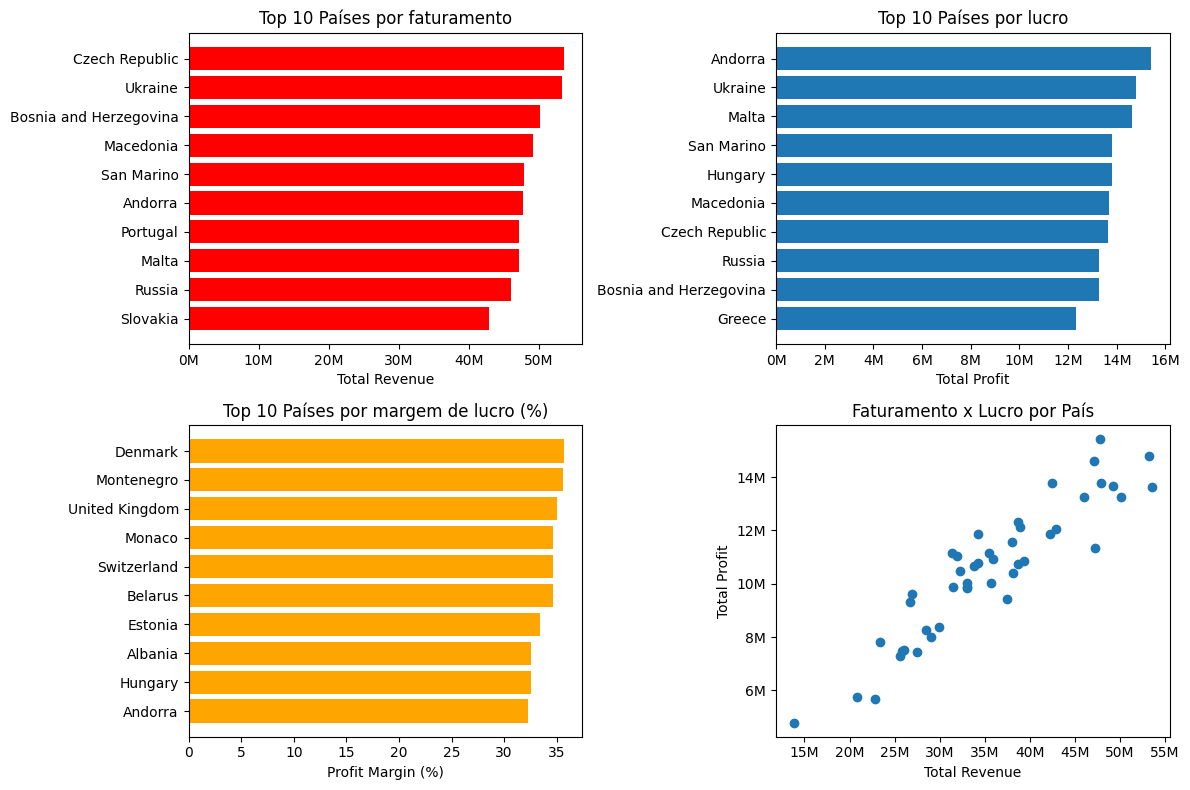

In [ ]:
from matplotlib.ticker import FuncFormatter

def millions(x, pos):
    # Divide por 1 milhão e converte para inteiro
    return f'{int(x/1_000_000)}M'


# Preparar dados
top10_revenue = country_summary.sort_values(
    by='total_revenue',
    ascending=False
).head(10)

top10_profit = country_summary.sort_values(
    by='total_profit',
    ascending=False
).head(10)

top10_margin = country_summary.sort_values(
    by='profit_margin_%',
    ascending=False
).head(10)

# Criar figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ==============================
# 1️⃣ Top 10 Receita
# ==============================
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(millions))
axes[0, 0].barh(top10_revenue['country'], top10_revenue['total_revenue'], color="red")
axes[0, 0].set_title('Top 10 Países por faturamento')
axes[0, 0].set_xlabel('Total Revenue')
axes[0, 0].invert_yaxis()

# ==============================
# 2️⃣ Top 10 Lucro
# ==============================
axes[0, 1].xaxis.set_major_formatter(FuncFormatter(millions))
axes[0, 1].barh(top10_profit['country'], top10_profit['total_profit'])
axes[0, 1].set_title('Top 10 Países por lucro')
axes[0, 1].set_xlabel('Total Profit')
axes[0, 1].invert_yaxis()

# ==============================
# 3️⃣ Top 10 Margem
# ==============================
axes[1, 0].barh(top10_margin['country'], top10_margin['profit_margin_%'], color="orange")
axes[1, 0].set_title('Top 10 Países por margem de lucro (%)')
axes[1, 0].set_xlabel('Profit Margin (%)')
axes[1, 0].invert_yaxis()

# ==============================
# 4️⃣ Receita vs Lucro (Scatter)
# ==============================
axes[1, 1].scatter(
    country_summary['total_revenue'],
    country_summary['total_profit']
)
axes[1, 1].xaxis.set_major_formatter(FuncFormatter(millions))
axes[1, 1].yaxis.set_major_formatter(FuncFormatter(millions))
axes[1, 1].set_title('Faturamento x Lucro por País')
axes[1, 1].set_xlabel('Total Revenue')
axes[1, 1].set_ylabel('Total Profit')

plt.tight_layout()
plt.show()


##Métricas por regiões

In [ ]:
region_summary = df_merged.groupby('region').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    total_orders=('order_id', 'count')
).reset_index()

# Cálculo de métricas derivadas
region_summary['avg_revenue_per_order'] = (
    region_summary['total_revenue'] / region_summary['total_orders']
)

region_summary['avg_profit_per_order'] = (
    region_summary['total_profit'] / region_summary['total_orders']
)

region_summary['profit_margin_%'] = (
    region_summary['total_profit'] / region_summary['total_revenue']
) * 100

# Ordenar por receita (ranking principal)
region_summary = region_summary.sort_values(
    by='total_revenue',
    ascending=False
)

region_summary.head()


,region,total_units_sold,total_revenue,total_profit,total_orders,avg_revenue_per_order,avg_profit_per_order,profit_margin_%
1,Europe,5771150.0,1.508147e+09,4.489642e+08,1166,1.293437e+06,385046.497333,29.769255
0,Asia,410427.0,9.333089e+07,2.515225e+07,82,1.138182e+06,306734.792073,26.949549


#Gráficos métricas por regiões

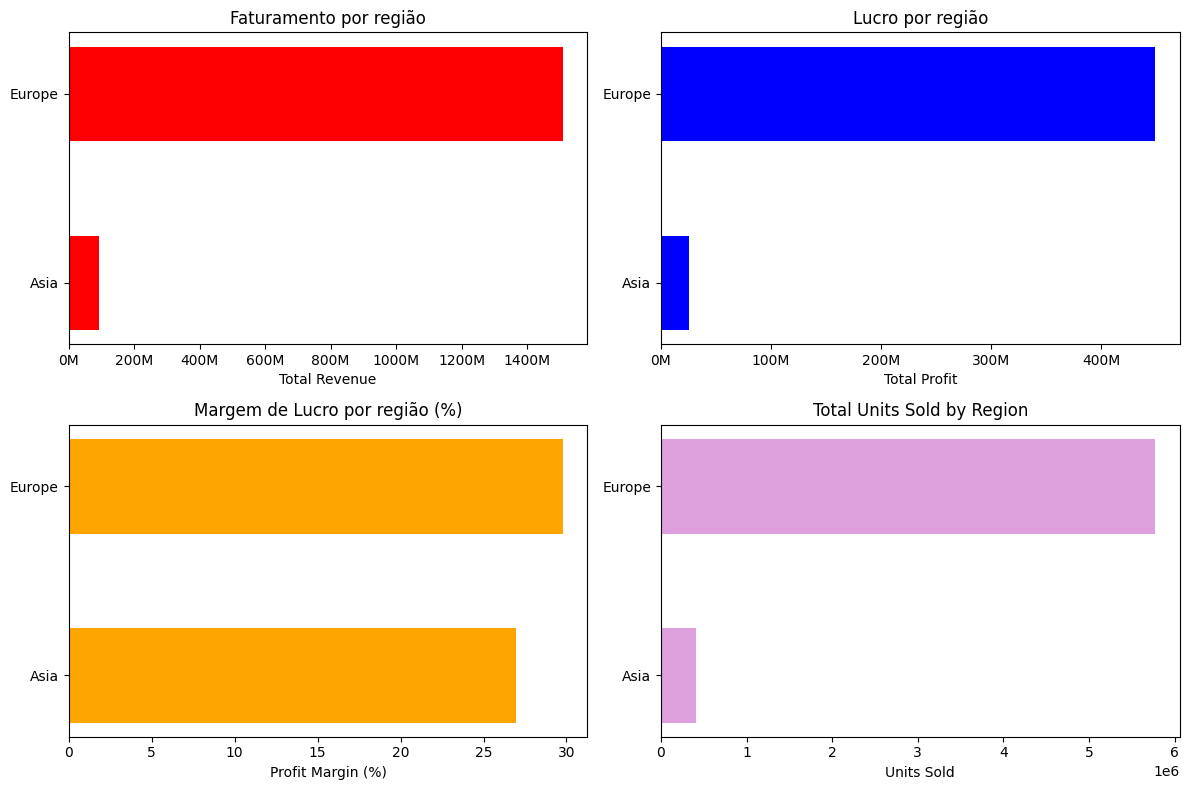

In [ ]:
from matplotlib.ticker import FuncFormatter

# Função para formatar valores em milhões sem casas decimais
def millions(x, pos):
    return f'{int(x/1_000_000)}M'

# Como temos só duas regiões, podemos usar diretamente todas
top_regions_revenue = region_summary.sort_values(by='total_revenue', ascending=False)
top_regions_profit = region_summary.sort_values(by='total_profit', ascending=False)
top_regions_margin = region_summary.sort_values(by='profit_margin_%', ascending=False)
top_regions_units = region_summary.sort_values(by='total_units_sold',ascending=False)

# Criar figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ==============================
# 1️⃣ Receita por Região
# ==============================
axes[0, 0].barh(top_regions_revenue['region'], top_regions_revenue['total_revenue'], color='red', height=0.5)
axes[0, 0].set_title('Faturamento por região')
axes[0, 0].set_xlabel('Total Revenue')
axes[0, 0].invert_yaxis()
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(millions))

# ==============================
# 2️⃣ Lucro por Região
# ==============================
axes[0, 1].barh(top_regions_profit['region'], top_regions_profit['total_profit'], color='blue', height=0.5)
axes[0, 1].set_title('Lucro por região')
axes[0, 1].set_xlabel('Total Profit')
axes[0, 1].invert_yaxis()
axes[0, 1].xaxis.set_major_formatter(FuncFormatter(millions))

# ==============================
# 3️⃣ Margem por Região
# ==============================
axes[1, 0].barh(top_regions_margin['region'], top_regions_margin['profit_margin_%'], color='orange', height=0.5)
axes[1, 0].set_title('Margem de Lucro por região (%)')
axes[1, 0].set_xlabel('Profit Margin (%)')
axes[1, 0].invert_yaxis()

# ==============================
# 4️⃣ Total de Vendas por Região
# ==============================
axes[1, 1].barh(top_regions_units['region'], top_regions_units['total_units_sold'], color='plum', height=0.5)
axes[1, 1].set_title('Total Units Sold by Region')
axes[1, 1].set_xlabel('Units Sold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()


##Métricas por canais de vendas: Online x Offline

In [ ]:
# Quando rodei o código pela primeira vez percebi a ocorrência de online e Online, então estou padronizando os nomes
df_merged['sales_channel'] = df_merged['sales_channel'].str.replace('online', 'Online')

channel_summary = df_merged.groupby('sales_channel').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()

# Ordenar por receita (opcional)
channel_summary = channel_summary.sort_values(by='total_revenue', ascending=False)

channel_summary


,sales_channel,total_units_sold,total_revenue,total_profit
0,Offline,3123318.0,8.125249e+08,2.389188e+08
1,Online,3058259.0,7.889533e+08,2.351977e+08


##Gráficos das métricas por canais de vendas

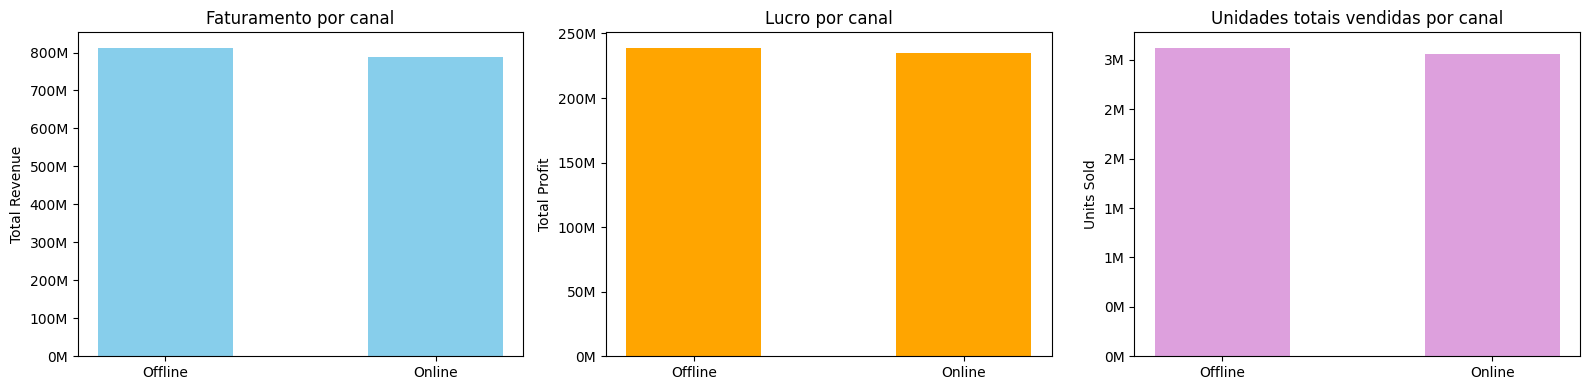

In [ ]:
from matplotlib.ticker import FuncFormatter

# Função para formatar valores em milhões sem casas decimais
def millions(x, pos):
    return f'{int(x/1_000_000)}M'

# Preparar dados
top_channels_revenue = channel_summary.sort_values(by='total_revenue', ascending=False)
top_channels_profit = channel_summary.sort_values(by='total_profit', ascending=False)
top_channels_units = channel_summary.sort_values(by='total_units_sold', ascending=False)

# Criar figura 1x3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ==============================
# 1️⃣ Receita por Canal
# ==============================
axes[0].bar(top_channels_revenue['sales_channel'], top_channels_revenue['total_revenue'], color='skyblue', width=0.5)
axes[0].set_title('Faturamento por canal')
axes[0].set_ylabel('Total Revenue')
axes[0].yaxis.set_major_formatter(FuncFormatter(millions))

# ==============================
# 2️⃣ Lucro por Canal
# ==============================
axes[1].bar(top_channels_profit['sales_channel'], top_channels_profit['total_profit'], color='orange', width=0.5)
axes[1].set_title('Lucro por canal')
axes[1].set_ylabel('Total Profit')
axes[1].yaxis.set_major_formatter(FuncFormatter(millions))

# ==============================
# 3️⃣ Total de Vendas por Canal
# ==============================
axes[2].bar(top_channels_units['sales_channel'], top_channels_units['total_units_sold'], color='plum', width=0.5)
axes[2].set_title('Unidades totais vendidas por canal')
axes[2].set_ylabel('Units Sold')
axes[2].yaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()


##Métricas por categorias de produtos

In [ ]:
# Criar coluna de custo total por pedido
df_merged['total_cost'] = df_merged['unit_cost'] * df_merged['units_sold']

# Agora o agrupamento fica simples
product_summary = df_merged.groupby('product_category').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum'),
    total_cost=('total_cost', 'sum')
).reset_index()

product_summary = product_summary.sort_values(by='total_revenue', ascending=False)

product_summary



,product_category,total_units_sold,total_revenue,total_profit,total_cost
8,Office Supplies,581481.0,3.786662e+08,73411976.25,3.052543e+08
6,Household,417308.0,2.788744e+08,69160454.84,2.097140e+08
4,Cosmetics,506188.0,2.213054e+08,88010907.56,1.332945e+08
7,Meat,482186.0,2.034295e+08,27581039.20,1.758484e+08
0,Baby Food,524265.0,1.338344e+08,50256042.90,8.357833e+07
2,Cereal,460266.0,9.467672e+07,40774964.94,5.390175e+07
11,Vegetables,532510.0,8.203849e+07,33617356.30,4.842113e+07
10,Snacks,453621.0,6.921349e+07,25012661.94,4.420083e+07
3,Clothes,579313.0,6.330732e+07,42544746.72,2.076258e+07
9,Personal Care,535313.0,4.375113e+07,13414943.78,3.033619e+07


#Gráficos métricas categorias de produtos

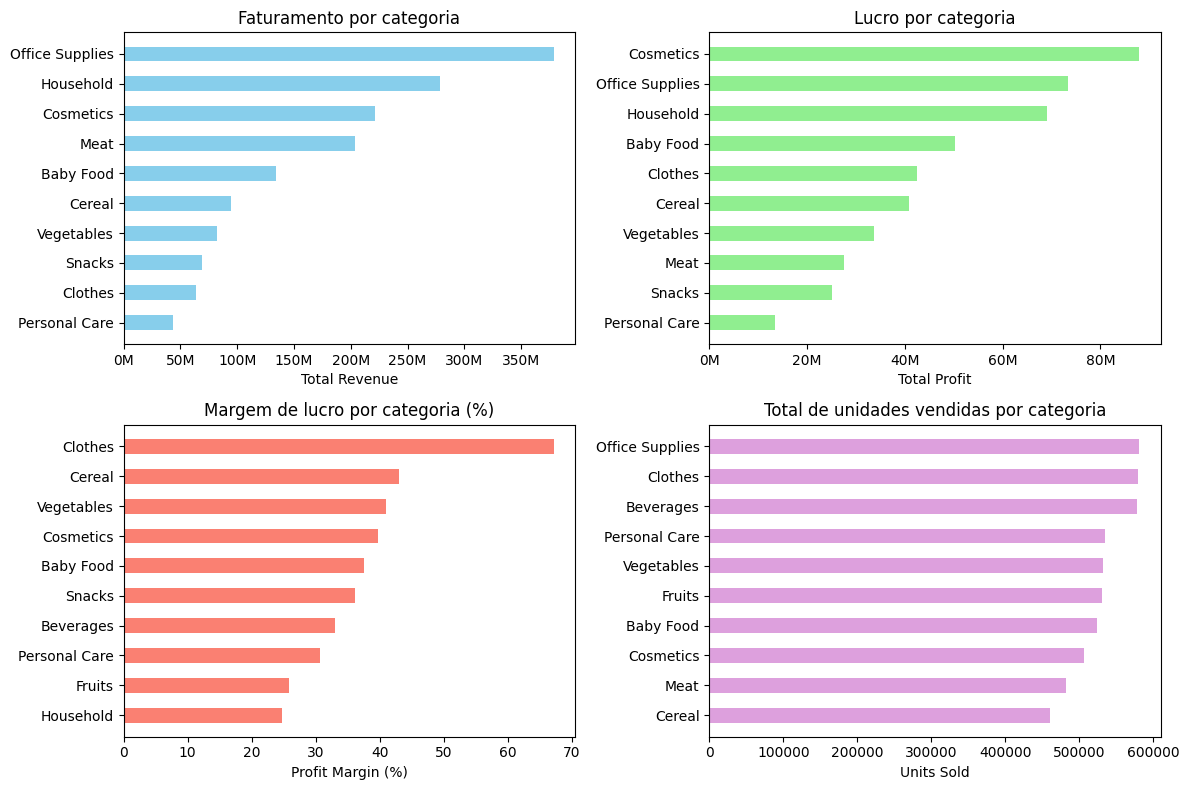

In [ ]:
from matplotlib.ticker import FuncFormatter

# Função para formatar valores em milhões sem casas decimais
def millions(x, pos):
    return f'{int(x/1_000_000)}M'

# Preparar dados para cada gráfico (Top 10 produtos por métrica)
top10_revenue = product_summary.sort_values(by='total_revenue', ascending=False).head(10)
top10_profit = product_summary.sort_values(by='total_profit', ascending=False).head(10)
top10_margin = product_summary.sort_values(by='total_profit', ascending=False).head(10)  # margem derivada se quiser, ou recalcular
top10_units = product_summary.sort_values(by='total_units_sold', ascending=False).head(10)

# Calcular margem %
product_summary['profit_margin_%'] = (product_summary['total_profit'] / product_summary['total_revenue']) * 100
top10_margin = product_summary.sort_values(by='profit_margin_%', ascending=False).head(10)

# Criar figura 2x2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ==============================
# 1️⃣ Receita por categoria
# ==============================
axes[0, 0].barh(top10_revenue['product_category'], top10_revenue['total_revenue'], color='skyblue', height=0.5)
axes[0, 0].set_title('Faturamento por categoria')
axes[0, 0].set_xlabel('Total Revenue')
axes[0, 0].invert_yaxis()
axes[0, 0].xaxis.set_major_formatter(FuncFormatter(millions))

# ==============================
# 2️⃣ Lucro por categoria
# ==============================
axes[0, 1].barh(top10_profit['product_category'], top10_profit['total_profit'], color='lightgreen', height=0.5)
axes[0, 1].set_title('Lucro por categoria')
axes[0, 1].set_xlabel('Total Profit')
axes[0, 1].invert_yaxis()
axes[0, 1].xaxis.set_major_formatter(FuncFormatter(millions))

# ==============================
# 3️⃣ Margem por categoria
# ==============================
axes[1, 0].barh(top10_margin['product_category'], top10_margin['profit_margin_%'], color='salmon', height=0.5)
axes[1, 0].set_title('Margem de lucro por categoria (%)')
axes[1, 0].set_xlabel('Profit Margin (%)')
axes[1, 0].invert_yaxis()

# ==============================
# 4️⃣ Total de Unidades Vendidas
# ==============================
axes[1, 1].barh(top10_units['product_category'], top10_units['total_units_sold'], color='plum', height=0.5)
axes[1, 1].set_title('Total de unidades vendidas por categoria')
axes[1, 1].set_xlabel('Units Sold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()


##Métricas por anos de operação

In [ ]:
# Extrair ano
df_merged['year'] = df_merged['order_date'].dt.year

# Agrupar por ano e calcular métricas
yearly_summary = df_merged.groupby('year').agg(
    total_units_sold=('units_sold', 'sum'),
    total_revenue=('revenue', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()


primeira_venda = df_merged["order_date"].min()
ultima_venda = df_merged["order_date"].max()

print("Primeira venda:", primeira_venda)
print("Última venda:", ultima_venda)


yearly_summary

Primeira venda: 2010-01-01 00:00:00
Última venda: 2017-07-22 00:00:00


,year,total_units_sold,total_revenue,total_profit
0,2010,807286.0,2.022544e+08,59817992.71
1,2011,856237.0,2.142123e+08,64367010.94
2,2012,979497.0,2.675604e+08,83070056.18
3,2013,728409.0,1.753561e+08,51221929.68
4,2014,847345.0,2.194690e+08,66386812.94
5,2015,712761.0,2.139870e+08,58226509.54
6,2016,770134.0,1.812781e+08,55100085.19
7,2017,479908.0,1.273608e+08,35926071.66


**Importante observar que o último ano de vendas, vai apenas até o dia 22/07, ou seja, não contempla um périodo inteiro como os outros anos**

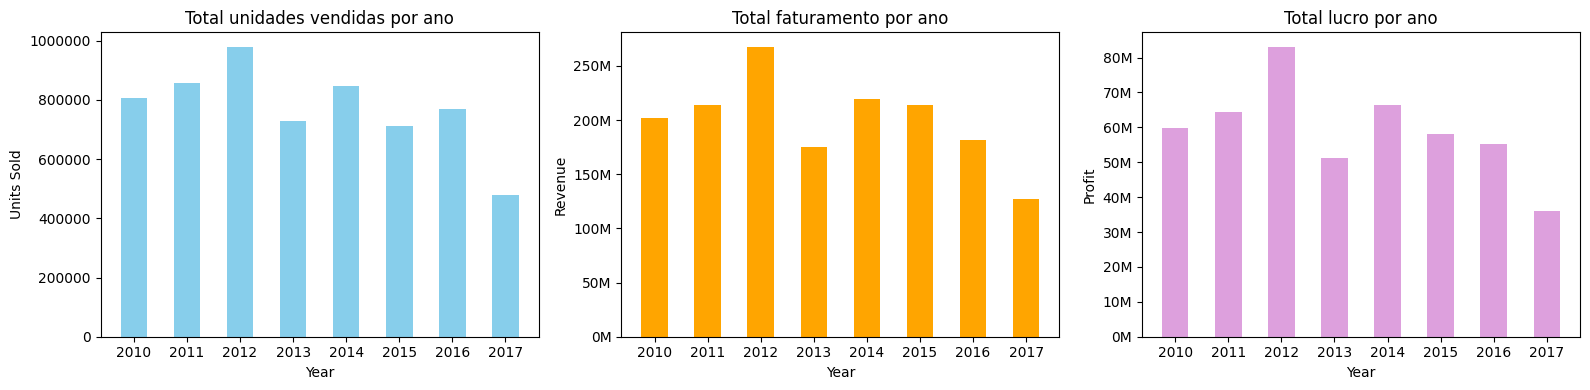

In [ ]:
from matplotlib.ticker import FuncFormatter

# Função para formatar valores em milhões sem casas decimais
def millions(x, pos):
    return f'{int(x/1_000_000)}M'


# Preparar os dados
years = yearly_summary['year']
units = yearly_summary['total_units_sold']
revenue = yearly_summary['total_revenue']
profit = yearly_summary['total_profit']

# Criar figura 1x3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ==============================
# 1️⃣ Total de Vendas por Ano
# ==============================
axes[0].bar(years, units, color='skyblue', width=0.5)
axes[0].set_title('Total unidades vendidas por ano')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Units Sold')
axes[0].ticklabel_format(style='plain', axis='y')

# ==============================
# 2️⃣ Receita por Ano
# ==============================
axes[1].bar(years, revenue, color='orange', width=0.5)
axes[1].set_title('Total faturamento por ano')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Revenue')
axes[1].yaxis.set_major_formatter(FuncFormatter(millions))

# ==============================
# 3️⃣ Lucro por Ano
# ==============================
axes[2].bar(years, profit, color='plum', width=0.5)
axes[2].set_title('Total lucro por ano')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Profit')
axes[2].yaxis.set_major_formatter(FuncFormatter(millions))

plt.tight_layout()
plt.show()


##Gráficos de tendências, vendas, faturamento e lucro ao longo dos anos

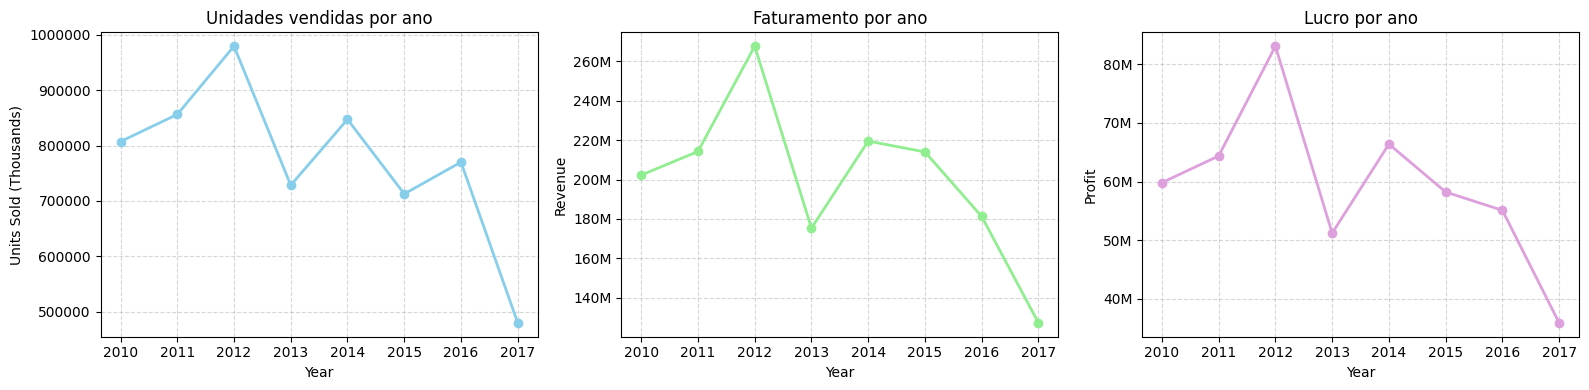

In [ ]:
from matplotlib.ticker import FuncFormatter

# Criar figura 1x3
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ==============================
# 1️⃣ Tendência de Vendas (em milhares)
# ==============================
axes[0].plot(years, units, marker='o', color='skyblue', linewidth=2)
axes[0].set_title('Unidades vendidas por ano')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Units Sold (Thousands)')
axes[0].ticklabel_format(style='plain', axis='y')  # evita notação científica
axes[0].grid(True, linestyle='--', alpha=0.5)

# ==============================
# 2️⃣ Tendência de Receita (em milhões)
# ==============================
axes[1].plot(years, revenue, marker='o', color='lightgreen', linewidth=2)
axes[1].set_title('Faturamento por ano')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Revenue')
axes[1].yaxis.set_major_formatter(FuncFormatter(millions))
axes[1].grid(True, linestyle='--', alpha=0.5)

# ==============================
# 3️⃣ Tendência de Lucro (em milhões)
# ==============================
axes[2].plot(years, profit, marker='o', color='plum', linewidth=2)
axes[2].set_title('Lucro por ano')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Profit')
axes[2].yaxis.set_major_formatter(FuncFormatter(millions))
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


##Métricas de vendas, lucro e faturamento por Mês

In [ ]:
# Criar coluna de mês
df_merged['month'] = df_merged['order_date'].dt.month_name()

# Agrupar por mês
monthly_metrics = df_merged.groupby('month').agg({
    'units_sold': 'sum',
    'revenue': 'sum',
    'profit': 'sum'
}).reset_index()

# Ordenar os meses corretamente
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
monthly_metrics['month'] = pd.Categorical(monthly_metrics['month'], categories=months_order, ordered=True)
monthly_metrics = monthly_metrics.sort_values('month')

# Mostrar tabela
monthly_metrics


,month,units_sold,revenue,profit
4,January,594625.0,1.506701e+08,50307253.59
3,February,499524.0,1.307131e+08,37276810.53
7,March,635482.0,1.611303e+08,47383965.51
0,April,482948.0,1.128493e+08,33339825.58
8,May,519776.0,1.421590e+08,42475573.58
6,June,555833.0,1.456073e+08,44602142.94
5,July,563203.0,1.484595e+08,43274350.42
1,August,408220.0,1.102181e+08,31404922.41
11,September,472398.0,1.240175e+08,39040699.07
10,October,501404.0,1.069044e+08,33357133.71


##Gráfico de tendência mensal

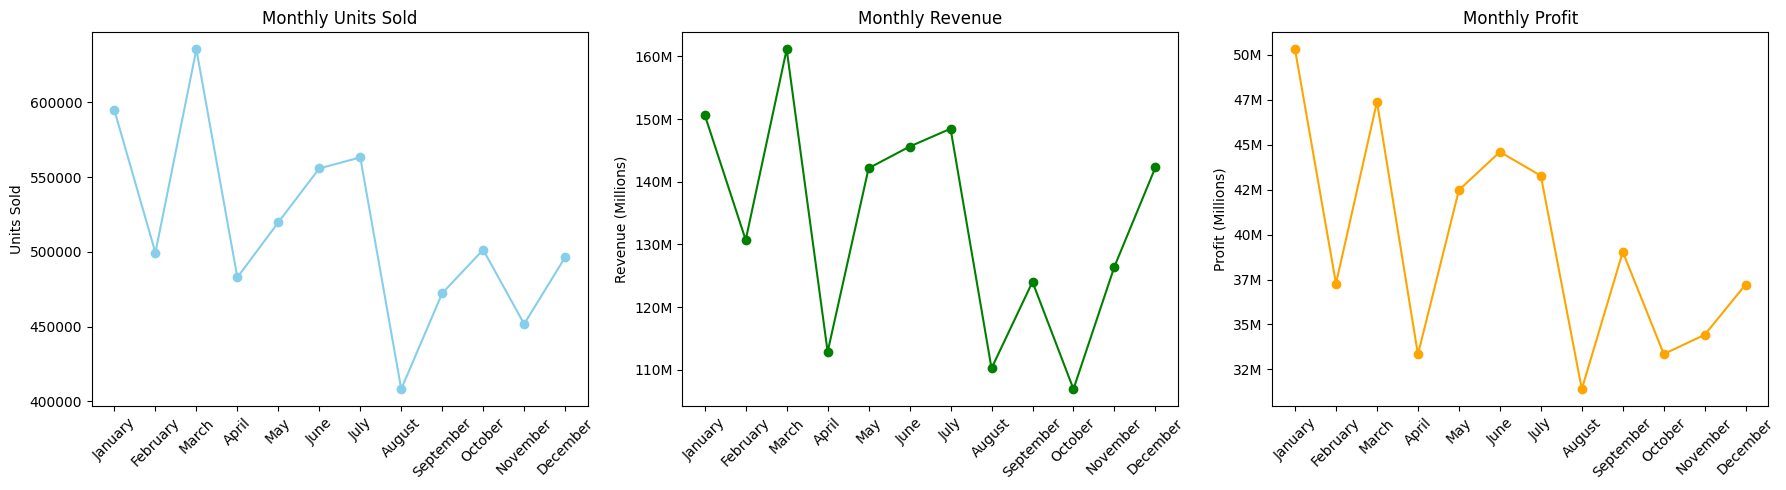

In [ ]:
from matplotlib.ticker import FuncFormatter

# Preparar dados
monthly_metrics_plot = monthly_metrics.copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# ------------------------
# 1️⃣ Vendas
axes[0].plot(
    monthly_metrics_plot['month'],
    monthly_metrics_plot['units_sold'],
    marker='o',
    color='skyblue'
)
axes[0].set_ylabel('Units Sold')
axes[0].set_title('Monthly Units Sold')
axes[0].tick_params(axis='x', rotation=45)

# ------------------------
# 2️⃣ Faturamento
axes[1].plot(
    monthly_metrics_plot['month'],
    monthly_metrics_plot['revenue'],
    marker='o',
    color='green'
)
axes[1].set_ylabel('Revenue (Millions)')
axes[1].set_title('Monthly Revenue')
axes[1].tick_params(axis='x', rotation=45)

# Formatar eixo Y em milhões
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M')
)

# ------------------------
# 3️⃣ Lucro
axes[2].plot(
    monthly_metrics_plot['month'],
    monthly_metrics_plot['profit'],
    marker='o',
    color='orange'
)
axes[2].set_ylabel('Profit (Millions)')
axes[2].set_title('Monthly Profit')
axes[2].tick_params(axis='x', rotation=45)

# Formatar eixo Y em milhões
axes[2].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M')
)

# ------------------------
plt.tight_layout()
plt.show()


##Métricas de vendas, faturamento e lucro por dias da semana

In [ ]:
# Criar coluna weekday (nome do dia da semana)
df_merged['weekday'] = df_merged['order_date'].dt.day_name()

# Agrupar por dia da semana
weekday_metrics = df_merged.groupby('weekday').agg({
    'units_sold': 'sum',
    'revenue': 'sum',
    'profit': 'sum'
}).reset_index()

# Ordenar os dias corretamente (Segunda → Domingo)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_metrics['weekday'] = pd.Categorical(weekday_metrics['weekday'], categories=days_order, ordered=True)
weekday_metrics = weekday_metrics.sort_values('weekday')

# Mostrar tabela
weekday_metrics


,weekday,units_sold,revenue,profit
1,Monday,938630.0,2.595599e+08,72281117.48
5,Tuesday,838928.0,2.069571e+08,63796178.59
6,Wednesday,839870.0,2.448676e+08,67768122.43
4,Thursday,818022.0,2.032473e+08,60108355.32
0,Friday,787802.0,2.436208e+08,73323427.18
2,Saturday,970549.0,2.208222e+08,68743185.28
3,Sunday,987776.0,2.224033e+08,68096082.56


##Graficos de vendas, faturamento e lucro por dia da semana

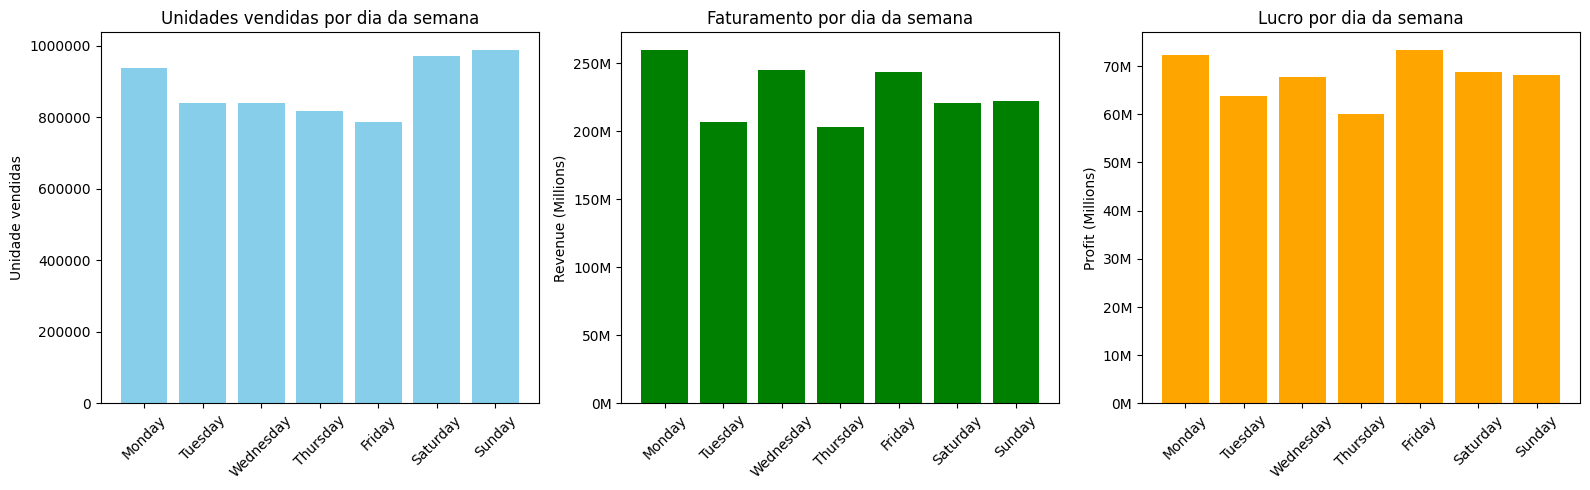

In [ ]:
# Preparar dados
weekday_metrics_plot = weekday_metrics.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

# ------------------------
# 1️⃣ Unidades vendidas
axes[0].bar(
    weekday_metrics_plot['weekday'],
    weekday_metrics_plot['units_sold'],
    color='skyblue'
)
axes[0].set_ylabel('Unidade vendidas')
axes[0].set_title('Unidades vendidas por dia da semana')
axes[0].tick_params(axis='x', rotation=45)
axes[0].ticklabel_format(style='plain', axis='y')

# ------------------------
# 2️⃣ Faturamento
axes[1].bar(
    weekday_metrics_plot['weekday'],
    weekday_metrics_plot['revenue'],
    color='green'
)
axes[1].set_ylabel('Revenue (Millions)')
axes[1].set_title('Faturamento por dia da semana')
axes[1].tick_params(axis='x', rotation=45)

# Formatar eixo Y em milhões
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M')
)

# ------------------------
# 3️⃣ Lucro
axes[2].bar(
    weekday_metrics_plot['weekday'],
    weekday_metrics_plot['profit'],
    color='orange'
)
axes[2].set_ylabel('Profit (Millions)')
axes[2].set_title('Lucro por dia da semana')
axes[2].tick_params(axis='x', rotation=45)

# Formatar eixo Y em milhões
axes[2].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M')
)

# ------------------------
plt.tight_layout()
plt.show()


#Analise sobre a correlação entre o tempo de envio e o lucro

In [ ]:
# Garantir que ship_date também é datetime
df_merged['ship_date'] = pd.to_datetime(df_merged['ship_date'])

# Calcular tempo de entrega em dias
df_merged['ship_days'] = (df_merged['ship_date'] - df_merged['order_date']).dt.days

# Visualizar alguns valores
df_merged[['order_id', 'order_date', 'ship_date', 'ship_days', 'profit']].head()


,order_id,order_date,ship_date,ship_days,profit
0,100640618,2014-10-08,2014-10-18,10,57583.50
1,100983083,2016-08-11,2016-08-11,0,176559.87
2,102230632,2017-05-13,2017-06-13,31,85998.24
3,103435266,2012-08-11,2012-09-18,38,119767.68
4,103450715,2015-03-15,2015-04-18,34,280275.00


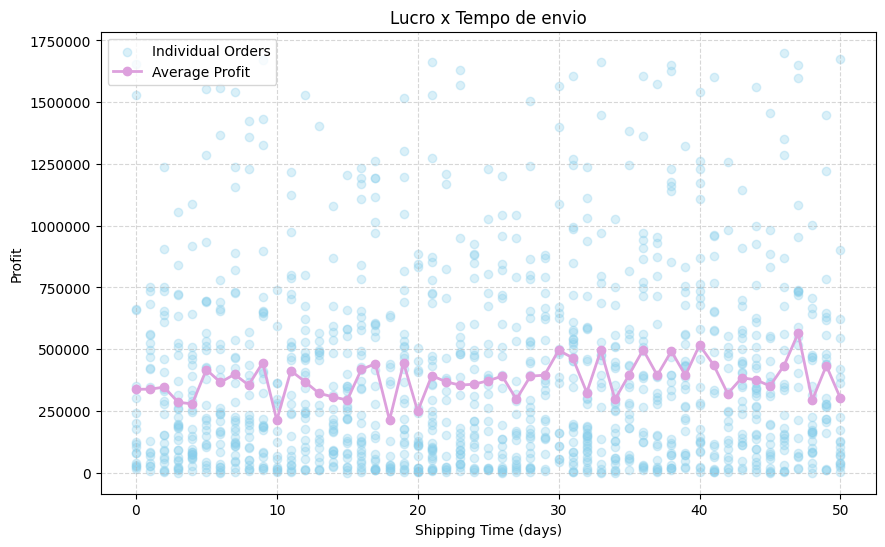

In [ ]:
# Calcular lucro médio por tempo de entrega
profit_by_ship = df_merged.groupby('ship_days')['profit'].mean().reset_index()

plt.figure(figsize=(10,6))

# Scatter de todos os pedidos
plt.scatter(df_merged['ship_days'], df_merged['profit'], alpha=0.3, color='skyblue', label='Individual Orders')

# Linha da média
plt.plot(profit_by_ship['ship_days'], profit_by_ship['profit'], marker='o', color='plum', linewidth=2, label='Average Profit')

plt.title('Lucro x Tempo de envio')
plt.xlabel('Shipping Time (days)')
plt.ylabel('Profit')
plt.grid(True, linestyle='--', alpha=0.5)
plt.ticklabel_format(style='plain', axis='y')
plt.legend()
plt.show()


##Métricas de popularidade das categorias pelos 10 Países com mais vendas

In [ ]:
# 1️⃣ Identificar Top 10 países por total de vendas
top_countries = df_merged.groupby('country')['units_sold'].sum() \
                         .sort_values(ascending=False).head(10).index

# 2️⃣ Filtrar dados para esses países
df_top = df_merged[df_merged['country'].isin(top_countries)]

# 3️⃣ Pivot table: categorias x países
pivot_top_categories = pd.pivot_table(
    df_top,
    index='product_category',   # linhas = categorias
    columns='country',          # colunas = países
    values='units_sold',        # métrica = número de vendas
    aggfunc='sum',              # somar unidades
    fill_value=0                # preencher zeros onde não houver vendas
).sort_values(by=top_countries[0], ascending=False)  # ordenar pela maior coluna

pivot_top_categories


country,Andorra,Cyprus,Greece,Macedonia,Malta,Romania,Russia,San Marino,Serbia,Ukraine
product_category,,,,,,,,,,
Beverages,29262.0,8383.0,24363.0,39284.0,8905.0,10565.0,12508.0,14681.0,29035.0,18442.0
Snacks,18748.0,22336.0,480.0,23340.0,9994.0,22441.0,23517.0,11303.0,13157.0,1443.0
Baby Food,19818.0,802.0,13788.0,19725.0,30499.0,24962.0,13734.0,8845.0,6798.0,1161.0
Office Supplies,3020.0,3636.0,9047.0,19574.0,11116.0,7679.0,29251.0,26215.0,22770.0,30205.0
Vegetables,12774.0,15427.0,12632.0,18581.0,14305.0,2809.0,5119.0,19611.0,38850.0,5794.0
Household,23532.0,16080.0,11245.0,17814.0,3062.0,3530.0,7488.0,10596.0,6115.0,3562.0
Clothes,8117.0,31672.0,9440.0,17767.0,0.0,15554.0,25606.0,21124.0,13657.0,7782.0
Fruits,13601.0,15863.0,28672.0,15694.0,21425.0,19438.0,9127.0,19166.0,9102.0,0.0
Meat,7355.0,14753.0,8209.0,15378.0,18728.0,13769.0,7392.0,10031.0,14798.0,19685.0


##Gráfico de popularidade de categorias pelo 10 países com mais vendas

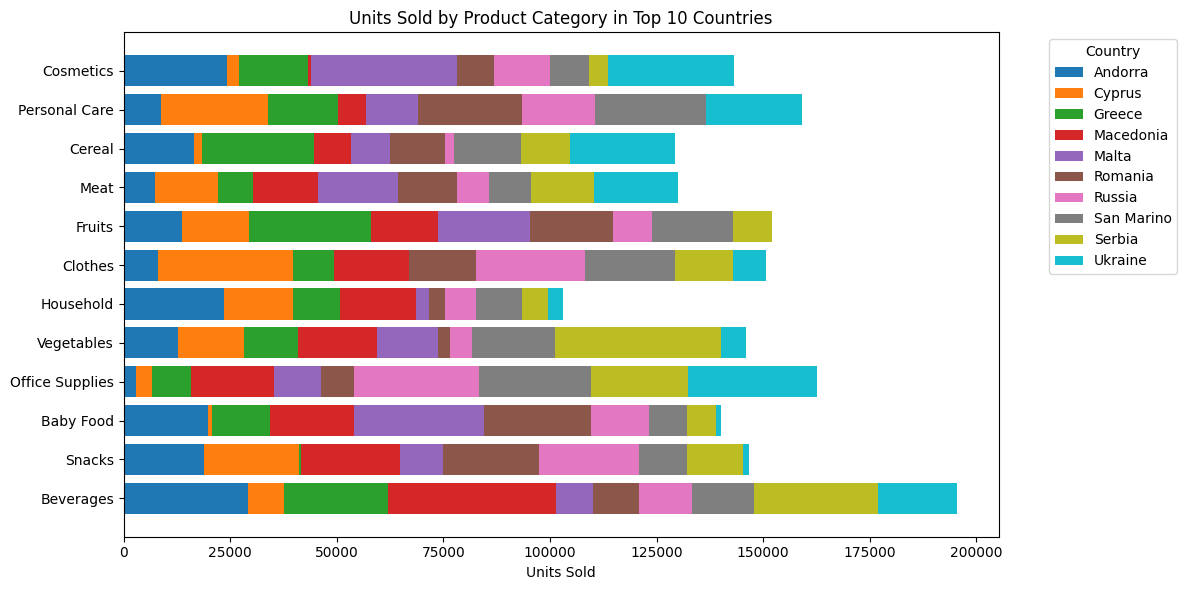

In [ ]:
import matplotlib.pyplot as plt

# Preparar dados da tabela pivot
pivot_data = pivot_top_categories.copy()

# Configurar cores (uma cor por país)
colors = plt.cm.tab10.colors  # 10 cores para 10 países

# Criar figura
fig, ax = plt.subplots(figsize=(12, 6))

# Barras empilhadas
bottom = [0] * len(pivot_data)  # inicializa base das barras

for i, country in enumerate(pivot_data.columns):
    ax.barh(
        pivot_data.index,
        pivot_data[country],
        left=bottom,
        color=colors[i],
        label=country
    )
    # atualizar base para próxima barra
    bottom = [bottom[j] + pivot_data[country].iloc[j] for j in range(len(bottom))]

ax.set_xlabel('Units Sold')
ax.set_title('Units Sold by Product Category in Top 10 Countries')
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


##Métricas sobre a receita das categorias pelo 10 países com mais vendas

In [ ]:
# Top 10 países por faturamento total
top_countries_revenue = (
    df_merged.groupby('country')['revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top_revenue = df_merged[df_merged['country'].isin(top_countries_revenue)]


pivot_revenue_top10 = pd.pivot_table(
    df_top_revenue,
    index='product_category',
    columns='country',
    values='revenue',
    aggfunc='sum',
    fill_value=0
)

# Ordenar pelas categorias que mais geram receita no total
pivot_revenue_top10['Total_Revenue'] = pivot_revenue_top10.sum(axis=1)
pivot_revenue_top10 = pivot_revenue_top10.sort_values(
    by='Total_Revenue',
    ascending=False
)
pivot_revenue_top10 = pivot_revenue_top10.drop(columns='Total_Revenue')

pivot_revenue_top10



country,Andorra,Bosnia and Herzegovina,Czech Republic,Macedonia,Malta,Portugal,Russia,San Marino,Slovakia,Ukraine
product_category,,,,,,,,,,
Office Supplies,1966654.20,14212007.04,10139990.91,12746784.54,7238850.36,17527317.15,19048543.71,17071470.15,21624730.47,19669798.05
Household,15725729.64,13048640.02,22456545.08,11904561.78,2046242.74,5870083.68,5004005.76,7080988.92,3940788.19,2380377.74
Cosmetics,10556194.00,3414969.20,2440013.20,379926.80,14922947.60,2738183.60,5715515.60,3968027.20,9823884.00,12874665.60
Meat,3103000.95,6139765.17,8643260.43,6487824.42,7901155.92,11218898.88,3118610.88,4231978.59,70033.74,8304904.65
Baby Food,5059139.04,6141781.52,1982504.48,5035398.00,7785784.72,3241545.44,3506015.52,2257951.60,1234278.80,296380.08
Cereal,3395078.50,146047.00,4070803.00,1761409.10,1898405.30,3478592.70,399880.80,3227638.70,473727.10,5047672.30
Snacks,2860569.84,907240.68,2155802.82,3561217.20,1524884.52,2202339.72,3588223.86,1724611.74,1766418.66,220172.94
Vegetables,1967962.44,3788335.40,510554.84,2862588.86,2203828.30,0.00,788633.14,3021270.66,1436147.32,892623.64
Personal Care,719959.57,1606239.69,443712.17,530345.97,1000783.85,417149.92,1405347.35,2115907.97,503293.34,1840232.68


##Gráfico de faturamento das categorias pelos top 10 países com mais vendas

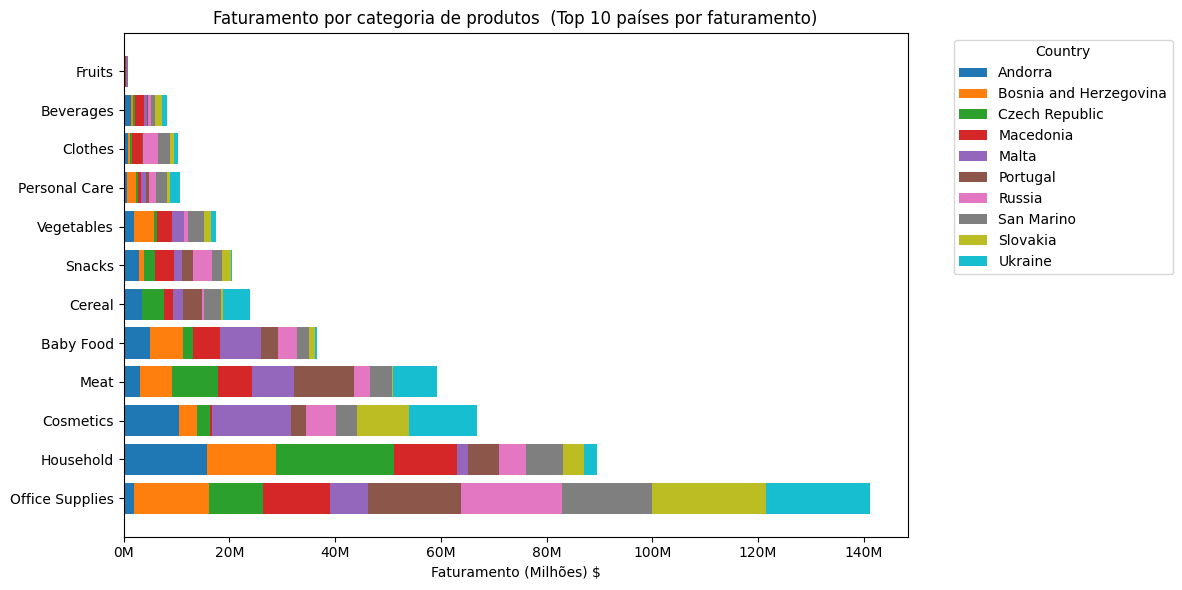

In [ ]:
pivot_data = pivot_revenue_top10.copy()

fig, ax = plt.subplots(figsize=(12, 6))

ax.set_xlabel('Faturamento (Milhões) $')
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M')
)

bottom = [0] * len(pivot_data)

for country in pivot_data.columns:
    ax.barh(
        pivot_data.index,
        pivot_data[country],
        left=bottom,
        label=country
    )

    bottom = [
        bottom[i] + pivot_data[country].iloc[i]
        for i in range(len(bottom))
    ]

ax.set_title('Faturamento por categoria de produtos  (Top 10 países por faturamento)')
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

##Métricas dos 10 países com maior lucro por categoria

In [ ]:
# 1️⃣ Top 10 países por lucro total
top_countries_profit = (
    df_merged.groupby('country')['profit']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

# 2️⃣ Filtrar apenas esses países
df_top_profit = df_merged[df_merged['country'].isin(top_countries_profit)]

# 3️⃣ Pivot table: lucro bruto por categoria e país
pivot_profit = pd.pivot_table(
    df_top_profit,
    index='product_category',   # linhas = categorias
    columns='country',          # colunas = países
    values='profit',            # métrica = lucro bruto
    aggfunc='sum',
    fill_value=0
)

# 4️⃣ Ordenar pelas categorias que mais geram lucro total
pivot_profit['Total_Profit'] = pivot_profit.sum(axis=1)
pivot_profit = pivot_profit.sort_values(by='Total_Profit', ascending=False)
pivot_profit = pivot_profit.drop(columns='Total_Profit')

pivot_profit


country,Andorra,Bosnia and Herzegovina,Czech Republic,Greece,Hungary,Macedonia,Malta,Russia,San Marino,Ukraine
product_category,,,,,,,,,,
Cosmetics,4198091.15,1358098.57,970368.47,2806957.28,4098463.64,151093.03,5934704.71,2273002.51,1578044.12,5120123.76
Office Supplies,381275.00,2755280.00,1965838.75,1142183.75,2123146.25,2471217.50,1403395.00,3692938.75,3309643.75,3813381.25
Household,3899958.36,3236043.98,5569190.92,1863633.85,1350865.23,2952314.22,507465.26,1240986.24,1756075.08,590330.26
Baby Food,1899753.48,2306295.74,744448.76,1321717.68,3880316.94,1890838.50,2923634.14,1316541.24,847881.70,111293.46
Cereal,1462177.95,62898.90,1753196.10,2341345.11,0.00,758596.17,817597.11,172218.96,1390065.69,2173910.01
Vegetables,806422.62,1552366.70,209212.82,797458.16,910965.90,1173018.53,903074.65,323162.47,1238042.43,365775.22
Clothes,596112.48,199463.04,216060.48,693273.60,767962.08,1304808.48,0.00,1880504.64,1551346.56,571510.08
Meat,420706.00,832431.60,1171856.40,469554.80,0.00,879621.60,1071241.60,422822.40,573773.20,1125982.00
Snacks,1033764.72,327862.44,779073.06,26467.20,172367.64,1286967.60,551069.16,1296727.38,623247.42,79567.02


##Gráfico dos top 10 países lucro x categoria

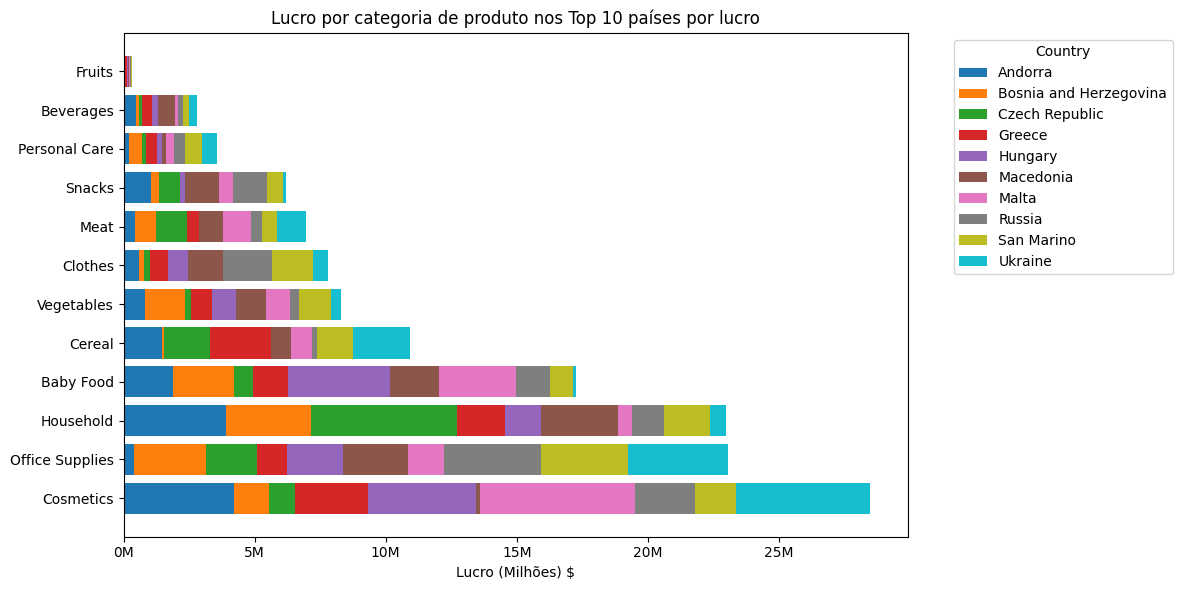

In [ ]:
from matplotlib.ticker import FuncFormatter

pivot_data = pivot_profit.copy()

fig, ax = plt.subplots(figsize=(12, 6))

bottom = [0] * len(pivot_data)

for country in pivot_data.columns:
    ax.barh(
        pivot_data.index,
        pivot_data[country],
        left=bottom,
        label=country
    )
    bottom = [bottom[i] + pivot_data[country].iloc[i] for i in range(len(bottom))]

# Formatação eixo X em milhões
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M')
)

ax.set_xlabel('Lucro (Milhões) $')
ax.set_title('Lucro por categoria de produto nos Top 10 países por lucro')
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


##Análise sobre a sazonalidade das categorias de produtos

/tmp/ipython-input-1620318066.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', n_categories)


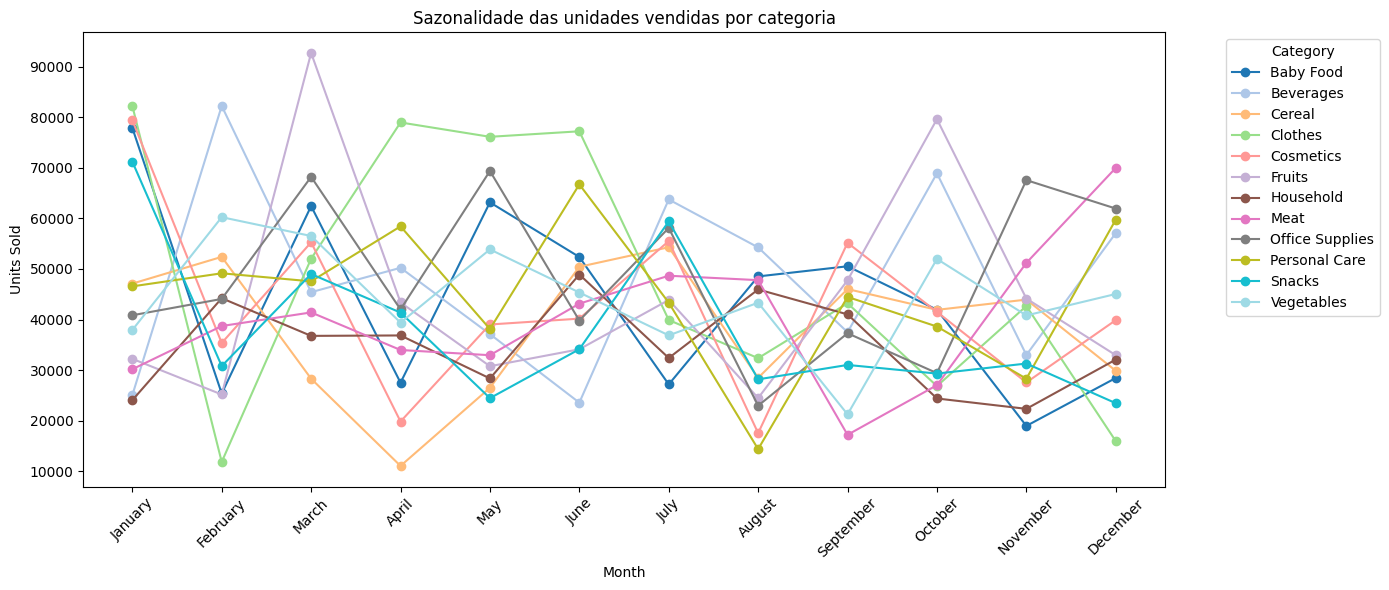

In [ ]:
import matplotlib.cm as cm

# Criar coluna de mês se ainda não existir
if 'month' not in df_merged.columns:
    df_merged['month'] = df_merged['order_date'].dt.month_name()

# Agrupar por categoria e mês para analisar a sazonalidade
seasonality_units = df_merged.groupby(['product_category', 'month']).agg(
    units_sold=('units_sold', 'sum')
).reset_index()

# Ordenar os meses corretamente
months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]
seasonality_units['month'] = pd.Categorical(
    seasonality_units['month'], categories=months_order, ordered=True
)
seasonality_units = seasonality_units.sort_values(['product_category', 'month'])

# ------------------------
# Lista de categorias
categories = seasonality_units['product_category'].unique()
n_categories = len(categories)

# Gerar cores automaticamente
cmap = cm.get_cmap('tab20', n_categories)
color_map = {cat: cmap(i) for i, cat in enumerate(categories)}

# ------------------------
# Gráfico de linhas
fig, ax = plt.subplots(figsize=(14, 6))

for category in categories:
    data = seasonality_units[seasonality_units['product_category'] == category]
    ax.plot(
        data['month'],
        data['units_sold'],
        marker='o',
        label=category,
        color=color_map[category]
    )

ax.set_title('Sazonalidade das unidades vendidas por categoria')
ax.set_ylabel('Units Sold')
ax.set_xlabel('Month')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##Análise da tendência de faturamento por anos dos top 10 países

/tmp/ipython-input-239745603.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', len(countries))


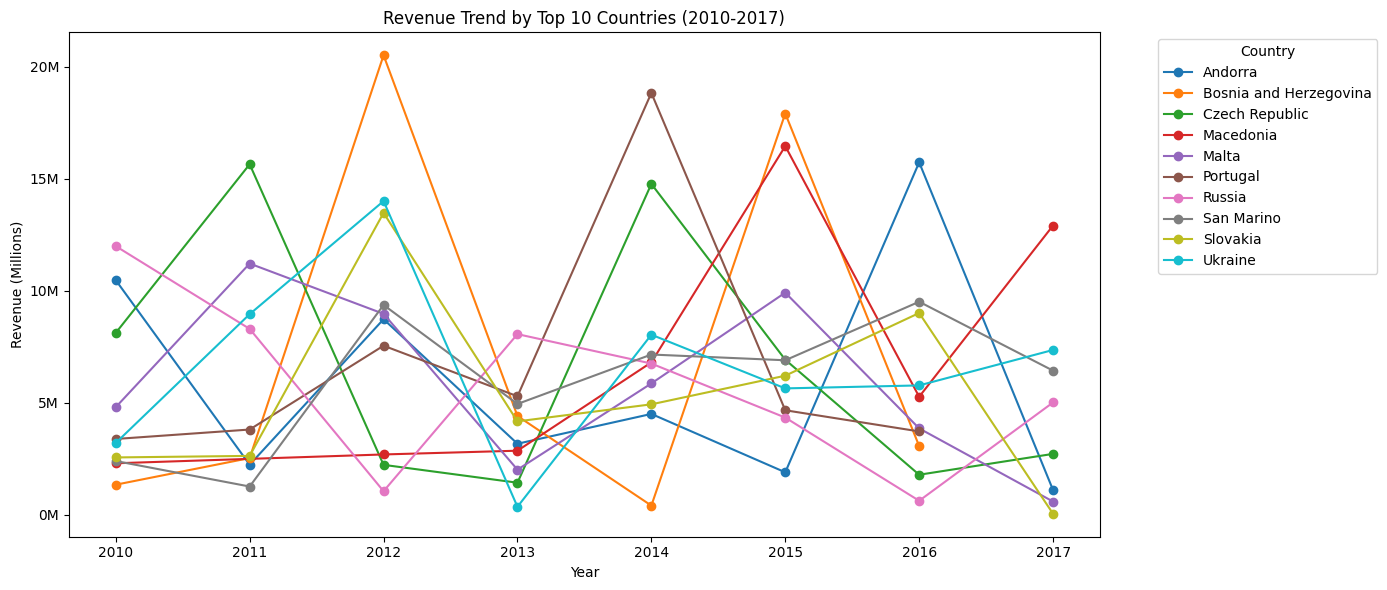

In [ ]:
# Top 10 países por faturamento total
top_countries = df_merged.groupby('country')['revenue'].sum().sort_values(ascending=False).head(10).index

df_top_countries = df_merged[df_merged['country'].isin(top_countries)].copy()
df_top_countries['year'] = df_top_countries['order_date'].dt.year
revenue_by_country_year = df_top_countries.groupby(['country', 'year'])['revenue'].sum().reset_index()

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.cm as cm

# Gerar cores automáticas para os 10 países
countries = revenue_by_country_year['country'].unique()
cmap = cm.get_cmap('tab10', len(countries))
color_map = {country: cmap(i) for i, country in enumerate(countries)}

# ------------------------
# Gráfico de linhas
fig, ax = plt.subplots(figsize=(14, 6))

for country in countries:
    data = revenue_by_country_year[revenue_by_country_year['country'] == country]
    ax.plot(
        data['year'],
        data['revenue'],
        marker='o',
        label=country,
        color=color_map[country]
    )

ax.set_title('Revenue Trend by Top 10 Countries (2010-2017)')
ax.set_ylabel('Revenue (Millions)')
ax.set_xlabel('Year')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x/1_000_000)}M'))
ax.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Esse gráfico deixa muito claro as tendências ao longos dos anos para cada país dos top 10 com maior faturamento. Se necessário ainda podem ser feitas investigações mais a fundo, como por exemplo, quais categorias representaram a maior queda

#Análise final

Começando a análise pelas métricas gerais dessa empresa. Vamos considerar o período entre o primeiro pedido feito no dia 01-01-2010 e o último pedido feito em 22-07-2017. Isso nos dá então um conjunto de dados de aproximadamente 6 anos e meio.

**Para as métricas gerais destaco:**


Número total de pedidos: 1248

Número total de unidades vendidas: 6181577.0

Receita total: $1,601,478,191.12

Lucro total: $474,116,468.84

Número total de países atendidos: 45

Número total de categoria produtos: 12

Número total de regiões atendidas: 2

Número total de sub regiões atendidas: 5


**Para as médias gerais da empresa temos os seguintes dados:**

Faturamento médio por venda: 1,283,235.73

Lucro médio por venda: 379,901.02

Custo médio por venda: 903,334.71

Margem de lucro: 29.60%

Para uma análise mais profunda com relação ao desempenho baseado nos dados apresentados acima, precisaria ter acesso a informações como os KPI’s dessa empresa, mas apenas olhando para os dados brutos, já podemos destacar que a empresa apresenta lucro o que é um excelente indicativo.


###Análises demográficas

Como o nosso conjunto de dados era muito extenso com relação aos países, busquei trabalhar sempre com os top 10 países por critério, vendas totais, faturamento e lucro.
Sugeri também uma comparação do faturamento x lucro por país e ficou clara a relação direta em que quanto maior o faturamento maior o lucro também.

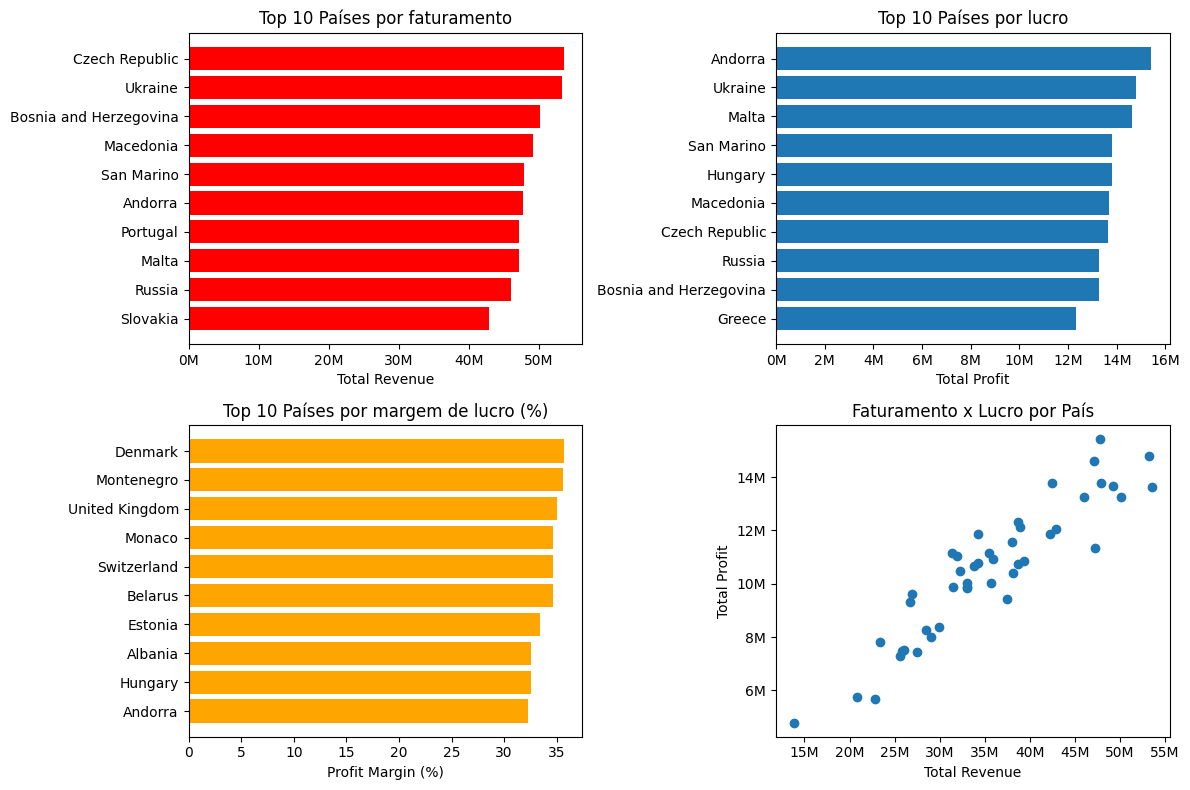

Como nos mostram os gráficos, não necessariamente o país com maior faturamento representa o maior lucro, isso se dá pelos custos que podem ser baseados em diversos fatores como por exemplo a categoria mais vendida naquele país que possui uma margem de lucro menor, como veremos a seguir em análises futuras.

Um destaque importante é Andorra, que mesmo sendo o 6º país em faturamento é o mais lucrativo, o que demonstra uma operação eficiente e custos mais baixos.
Outro ponto que é bom destacar é que existem diversos países que apresentam as mais altas margens de lucro e sequer estão presentes nas listas de faturamento ou lucro.

Esses mercados representam um grande potencial de investimento, já que podem trazer grandes resultados para a lucratividade dessa empresa. Recomendaria uma revisão estratégica para aumentar a participação dentro desses países baseado nessa métrica.

Quanto às regiões, pode-se observar um domínio absoluto da Europa, mas é importante destacar que a Ásia ainda possui uma boa margem de lucro, ficando pouco atrás do continente europeu nesse ponto, o que indica um mercado em potencial que vale a pena ser explorado caso esteja nos planos da empresa.

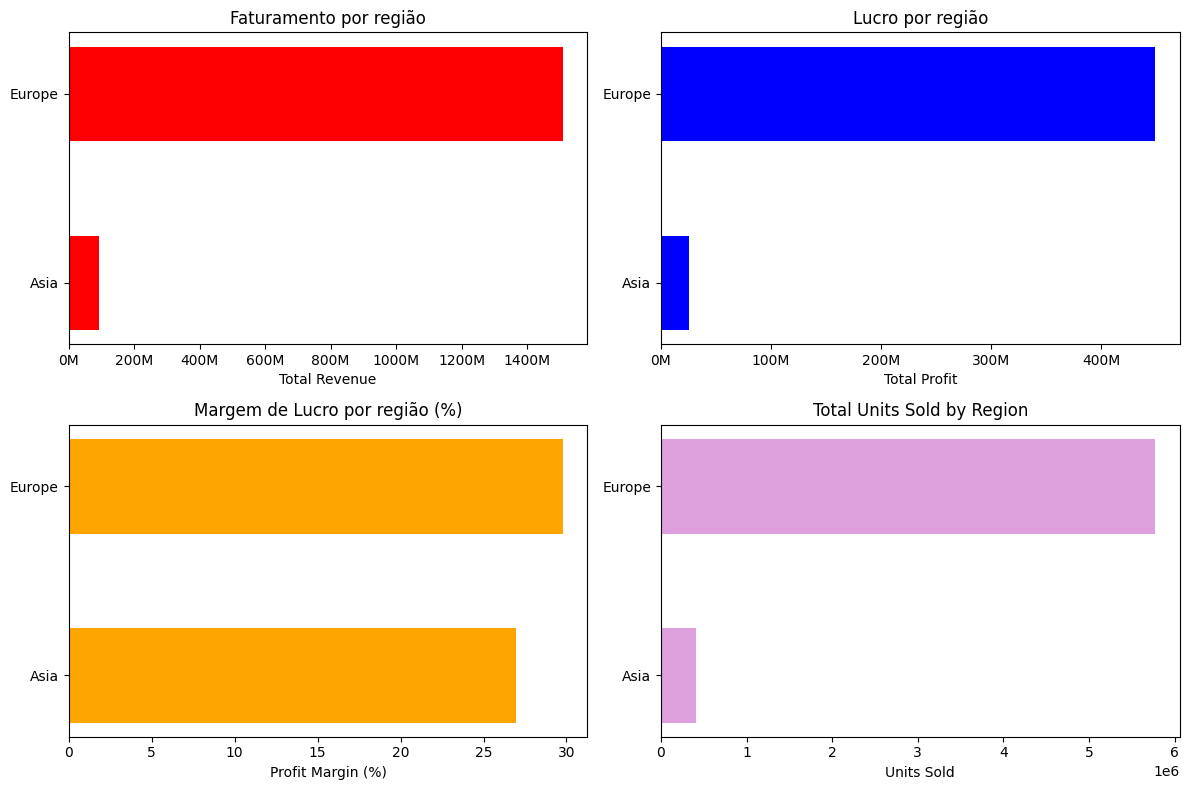


#Análise por canais de vendas Offline x Online

Logo de cara percebe-se um equilíbrio muito grande entre os dois canais de vendas. Em nenhuma das métricas observadas existe uma grande diferença, portanto, não destaco nenhum ponto importante que deve ser observado.

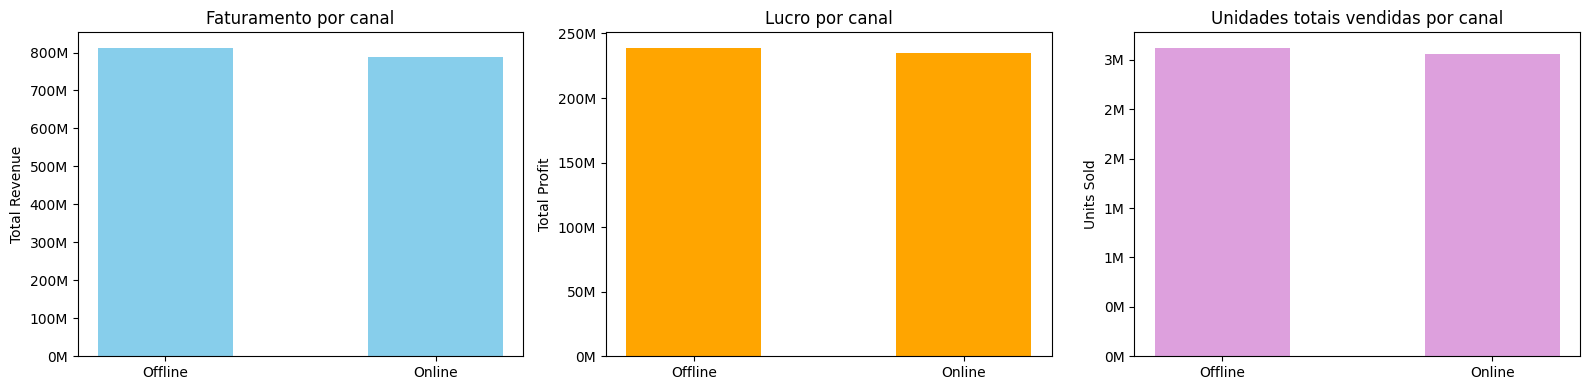


#Análise das categorias de produtos

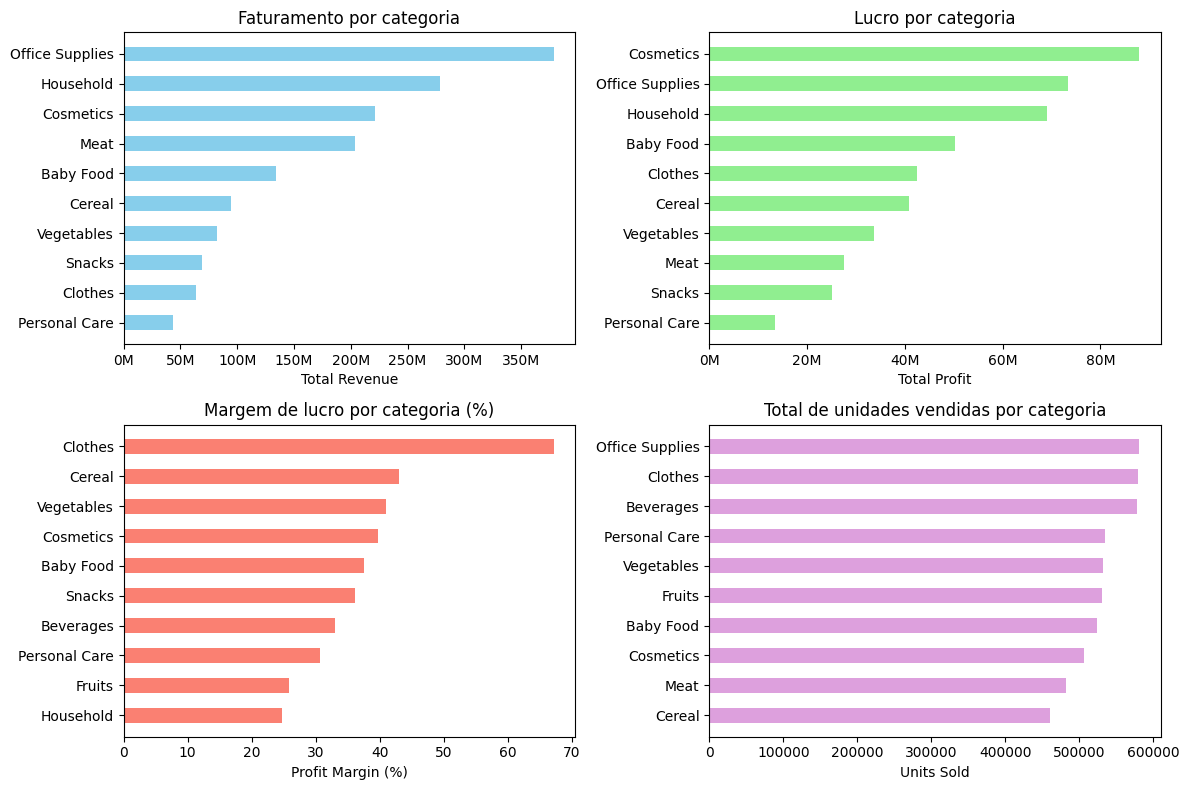

Nessa parte temos dados muito interessantes, destaque para as 3 principais categorias em faturamento que também são as 3 principais em lucro, alternando entre si as posições.

Nessa análise fica claro que a categoria Clothes possui uma margem de lucro muito acima das outras, mas não é tão participativa assim no lucro total. Isso se deve provavelmente a um ticket médio mais baixo com relação a outras categorias

Sugiro portanto atenção à oportunidade de crescimento que essa categoria apresenta, visto que ela é apenas a penúltima em faturamento mas possui um alto potencial para investimento.
Estratégias como upsell e cross-sell, por exemplo, podem ajudar a alavancar ainda mais a participação da categoria nos lucros totais, elevando o ticket médio da categoria.

Outro ponto importante é a categoria de Personal care. Ela está entre as 4 categorias com maior número de vendas, mas é a última tanto em faturamento e principalmente em lucro.
Como não tenho acesso ao planejamento da empresa, pode ser que essa categoria seja usada como entrada de mercado, mas ainda assim sugiro uma revisão nos KPI’s dela.



#Análises temporais e sazonais

A empresa tem dados distribuídos em um período de aproximadamente 6 anos e meio.
O ano de 2017 só possui dados até o dia 22-07 o que compromete um pouco a análise geral, mas podemos destacar alguns pontos importantes.

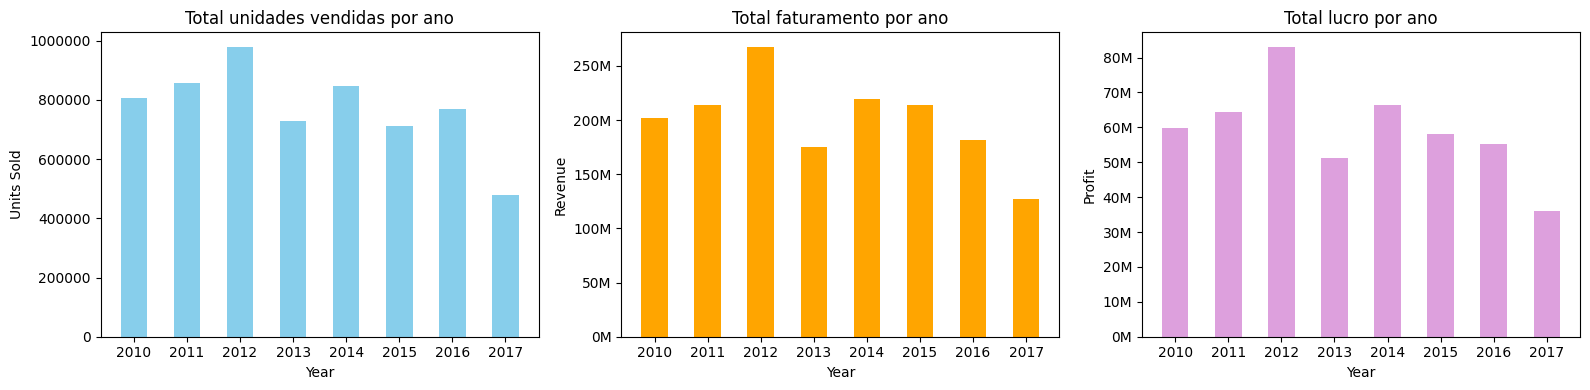

Nas 3 métricas analisadas, número total de vendas, faturamento e lucro, o ano de 2012 foi absolutamente superior nos 3 quesitos, seguido de uma forte queda no ano seguinte e um reajuste pros anos seguintes.


Como não possuo dados históricos complementares é difícil dizer o que aconteceu, mas fazendo uma breve pesquisa sobre os anos de 2012 e 2013 encontrei os seguintes resultados:


“O ano de 2012, possivelmente, representou um último pico de atividade antes de uma desaceleração mais pronunciada. A empresa pode ter sido impactada por uma conjunção de queda de demanda na Europa , crise cambial e financeira em mercados asiáticos chave  e aumento de custos operacionais “
Esse foi um resumo apresentado pelo deepseek em uma pesquisa sobre eventos financeiros nos anos citados.

Para uma melhor análise precisaria de um contexto histórico maior.

Para facilitar a visualização dessa tendência também proponho os seguintes gráficos:

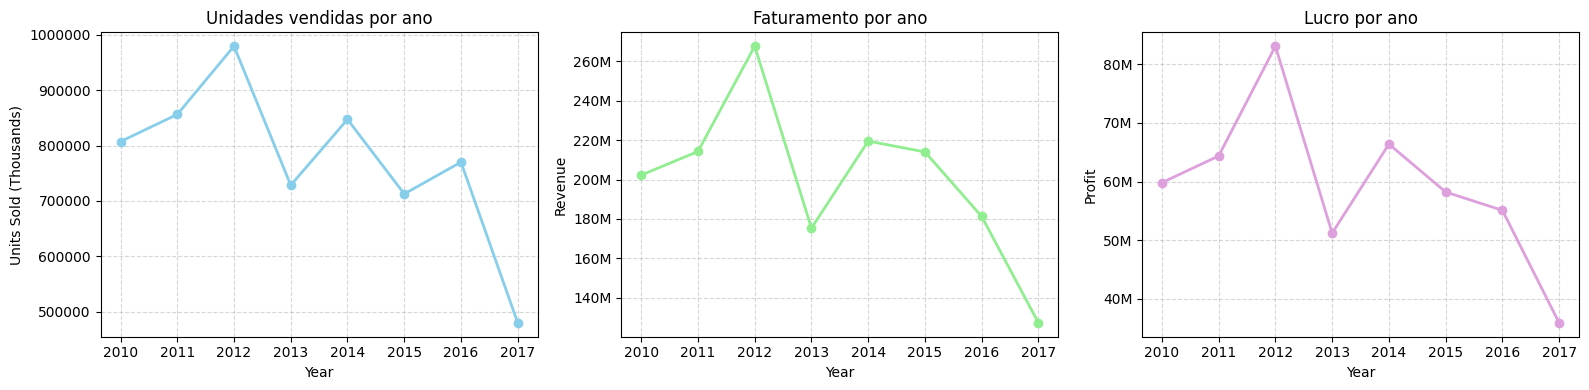

Partindo agora para uma análise de tendência sobre as métricas de vendas, faturamento e lucro por meses do ano, temos os seguintes resultados:

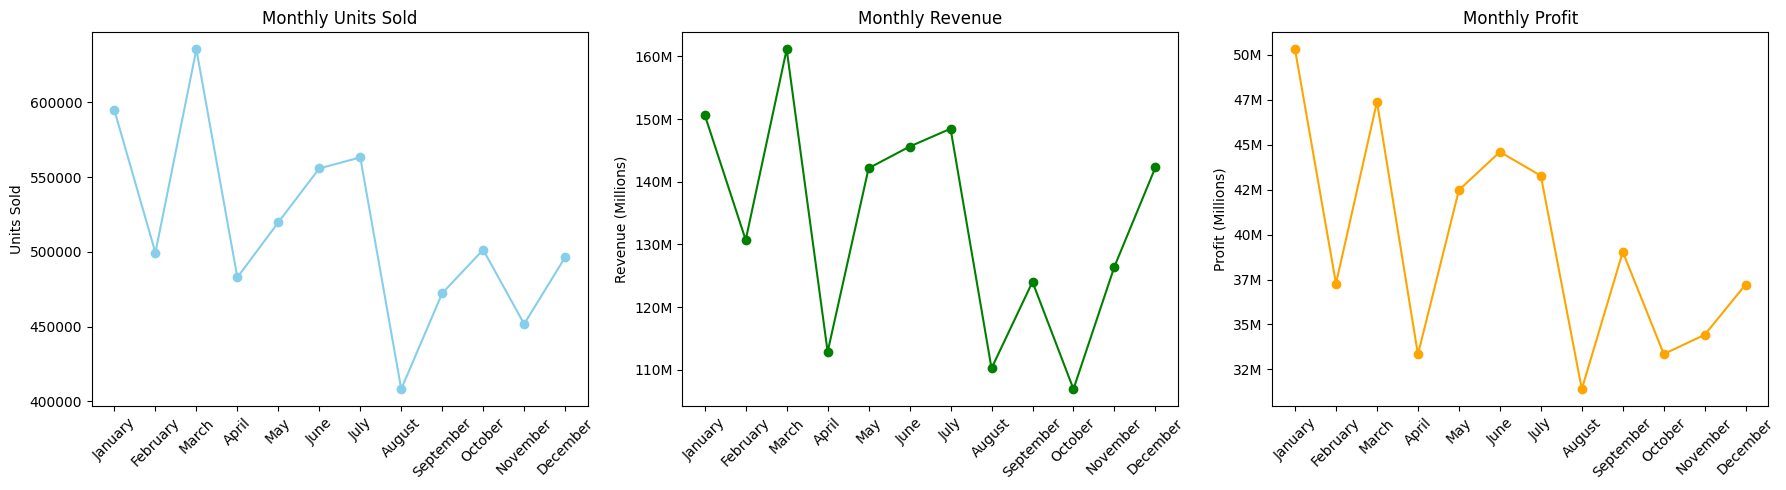

Os gráficos mostram que nos meses de agosto temos uma queda acentuada em todos os 3 quesitos, o que é um ponto de atenção urgente para futuras correções, seguido pelo mês de outubro que também não teve uma boa performance.

Quantos aos meses mais positivos, destacam-se principalmente março e julho.

Algo que eu sugiro prestar atenção é exatamente no quão grande tem sido a variação das performances de um mês para o outro, que fica explícito pela quantidade de vezes que a linha sobe e desce ao longo dos 3 gráficos.

Se tratando dos dias da semana, esses dados são mais homogêneos:


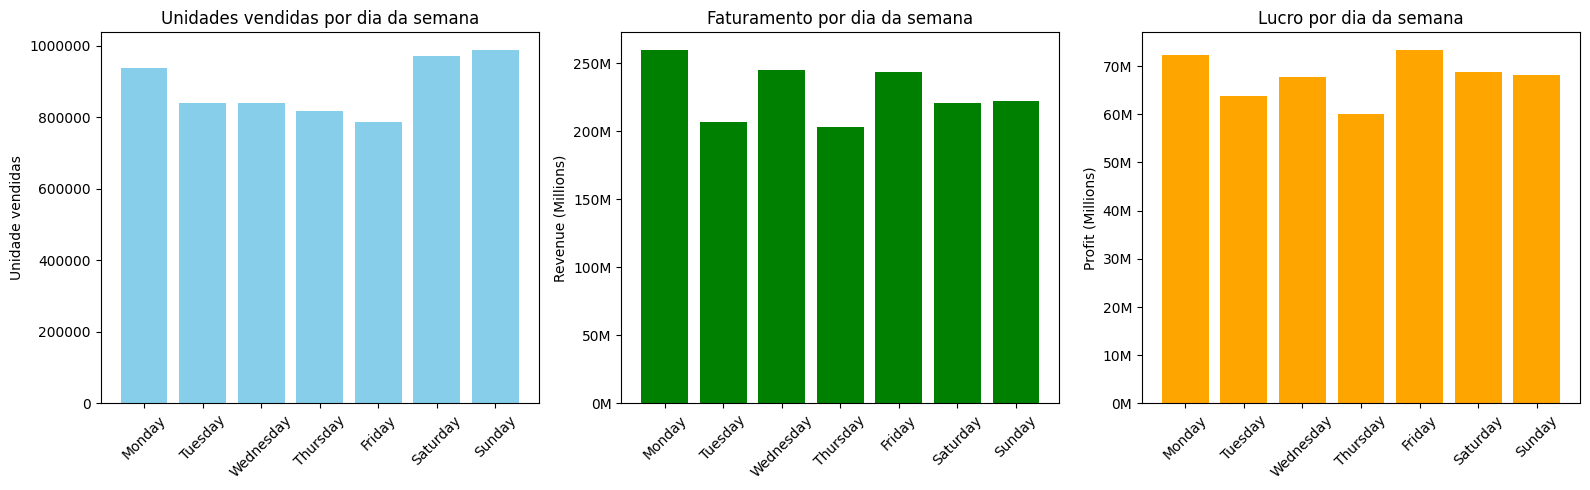

Um leve destaque para as segundas feiras que possuem excelentes indicadores nos 3 quesitos.



#Correlação tempo de envio x lucro

Uma comparação que foi sugerida era analisar se existia alguma correlação entre o tempo de envio de um pedido e o seu lucro.
Como pode-se observar no gráfico essa correlação é inexistente e não impactam o lucro da empresa:

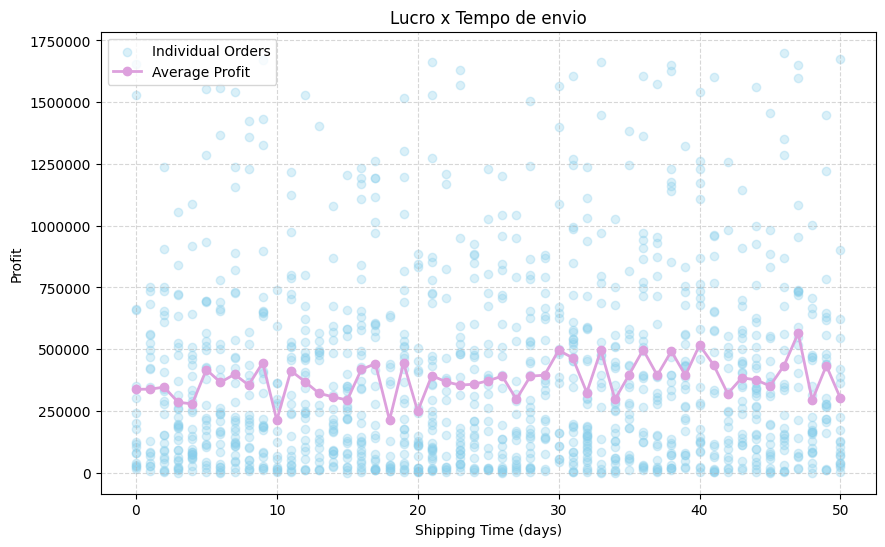



#Sazonalidade das categorias de produtos por meses

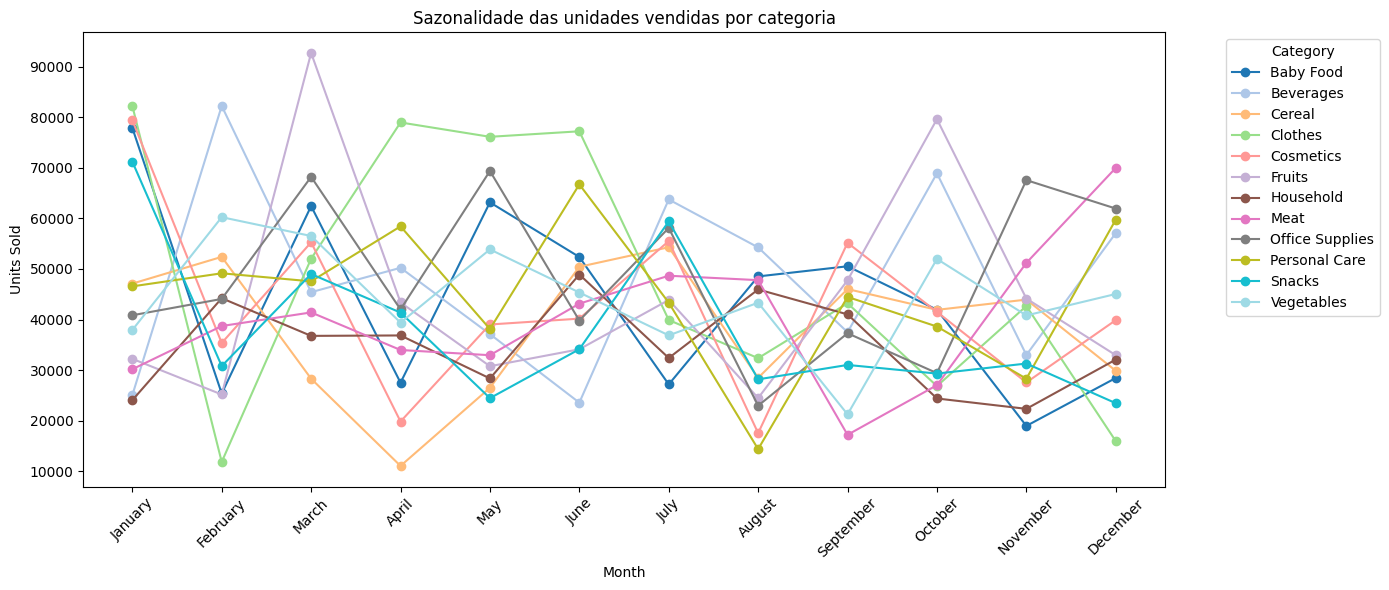

A categoria de frutas apresenta picos muito acentuados, o que provavelmente está ligada à sazonalidade de produção mesmo.

A categoria de Clothes, se manteve estável no período de março até junho, onde praticamente todas as outras tiveram quedas muito acentuadas, reforçando novamente a oportunidade de investimento nessa categoria.

Novamente a grande quantidade de variações nas vendas é um ponto que chama atenção, nenhuma das 12 categorias se manteve estável ao longo do período de um ano e salvo algumas pequenas anomalias, quase todas seguem a mesma tendência de alta e baixa.




#Análise sazonal do faturamento dos países pelos anos de operação

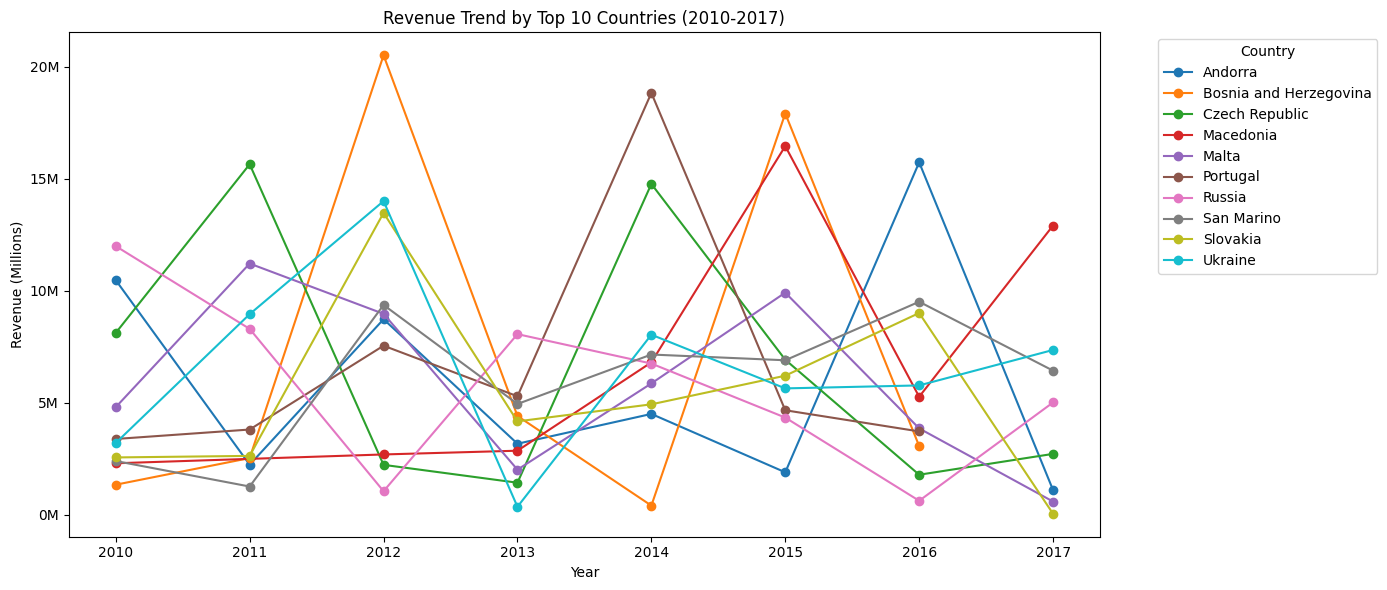

A Bósnia em 2012 foi a grande responsável pelo aumento do faturamento da empresa, mas infelizmente perdeu o seu potencial ao longo dos anos e nem sequer aparece nos dados de 2017. Seria interessante ter dados complementares para saber se as operações no país foram encerradas e quais os motivos para isso.

Talvez pela queda acentuada do ano de 2015 para 2016, a empresa decidiu não investir mais no país, em contrapartida a Macedônia, vem apresentando um crescimento muito interessante ao longo dos anos, sendo a líder em faturamento no ano de 2017 com a curva de crescimento mais acentuada. Ampliar os investimentos para esse país pode ser uma estratégia interessante para aproveitar o bom momento.

Outro país que demonstrou um comportamento diferente foi Andorra, que no ano de 2016 teve o maior crescimento dentre todos os países, mas em 2017 teve uma queda abrupta no faturamento.

Dos países mais regulares, destacam-se a Ucrânia e San Marino que mesmo com variações apresentaram uma linha mais homogênea ao longo do ano e por isso aparecem nos gráficos anteriores de faturamento e lucro como países protagonistas.


#Conclusões

A empresa teve variações altas nas métricas principais de faturamento, lucro e vendas nos anos de 2012 (alta) e nos anos de 2013 (queda), no resto do período analisado temos sim correções, porém menores dos que as citadas anteriormente.

Alguns pontos críticos devem ser observados, como por exemplo, a saída de países que faziam parte importante no faturamento e lucro e de repente não aparecem mais nos dados do último ano analisado.

Existem algumas oportunidades boas de investimentos como destacado por exemplo da categoria de roupas que possui uma margem de lucro muito interessante e ainda uma aceitação de mercado alta, visto seu alto número de unidades vendidas.

Olhando para os números gerais, pode-se destacar que uma margem de lucro de aproximadamente 30% costuma ser um bom indicativo sobre a estabilidade da empresa no mercado, mas para uma análise de desempenho mais assertiva seria necessário os KPI's que não temos acesso.

Outras análises mais aprofundadas ainda podem ser feitas, mas acredito que com os dados apresentandos já contemplo todos os requisitos da tarefa pedida